# **6CS012 - Artificial Intelligence and Machine Learning**


**Name**: Somiya Rai

**University ID**: 2432711

**Module Leader**: Mr.Siman Giri

**Tutor**: Mr. Anish Khatiwada

# Part II: Computer Vision Task

## Fruit Image Classification with Convolutional Neural Networks


## Environment Setup & Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']      = '3'   # block C++ INFO, WARNING, ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS']     = '0'   # suppress oneDNN info messages
os.environ['ABSL_MIN_LOG_LEVEL']        = '3'   # block absl (XLA service) logs
os.environ['GRPC_VERBOSITY']            = 'ERROR'
os.environ['CUDA_DEVICE_ORDER']         = 'PCI_BUS_ID'

# Core libraries
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')

# Evaluation metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import (ImageDataGenerator,
                                                   load_img, img_to_array)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Silence the absl logger that XLA uses (must be done after tf import)
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Pre-trained model for transfer learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Environment check
print('TensorFlow Version :', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU Available      :', 'YES —' + str(gpus) if gpus else 'NO (CPU mode)')
print('All imports successful')

E0000 00:00:1778401233.449099      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778401233.493018      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778401233.847944      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778401233.848006      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778401233.848012      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778401233.848016      57 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow Version : 2.19.0
GPU Available      : YES —[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
All imports successful


## Dataset Path Configuration

In [2]:
# Dataset paths (Kaggle auto-mounts under /kaggle/input)
TRAIN_DIR = "/kaggle/input/datasets/somiyarai/fruit-classification-dataset/fruits_dataset/Training"
TEST_DIR  = "/kaggle/input/datasets/somiyarai/fruit-classification-dataset/fruits_dataset/Test"

# Expected 15 fruit classes
EXPECTED_CLASSES = [
    'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Guava',
    'Kiwi', 'Lychee', 'Mango', 'Orange', 'Peach',
    'Pineapple', 'Pomegranate', 'Raspberry', 'Strawberry', 'Watermelon'
]

# Detect classes automatically from Training folder
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

# Quick check
print("Training directory :", TRAIN_DIR)
print("Test directory     :", TEST_DIR)
print("Classes detected   :", CLASS_NAMES)
print("Number of classes  :", NUM_CLASSES)

# Confirm class count
assert NUM_CLASSES == 15, f"Expected 15 classes, got {NUM_CLASSES}"
print("Class count check  : PASSED (15 classes confirmed)")


Training directory : /kaggle/input/datasets/somiyarai/fruit-classification-dataset/fruits_dataset/Training
Test directory     : /kaggle/input/datasets/somiyarai/fruit-classification-dataset/fruits_dataset/Test
Classes detected   : ['Apricot', 'Avocado', 'Banana', 'Blueberry', 'Guava', 'Kiwi', 'Lychee', 'Mango', 'Orange', 'Peach', 'Pineapple', 'Pomegranate', 'Raspberry', 'Strawberry', 'Watermelon']
Number of classes  : 15
Class count check  : PASSED (15 classes confirmed)


# 2.5 PartA: Designing and Analyzing Convolutional Neural Networks from Scratch

*(Section 2.5)*

## Section 2.5.1 — Data Understanding, Analysis, Visualization and Cleaning

In [3]:
# Count images per class in Training and Test directories
train_counts, test_counts = {}, {}

for cls in CLASS_NAMES:
    # Count number of images in each class folder
    train_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    test_counts[cls]  = len(os.listdir(os.path.join(TEST_DIR, cls)))

# Calculate totals
total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

# Print dataset overview table
print("=" * 62)
print("              DATASET OVERVIEW — FRUITS-360 (15 CLASSES)")
print("=" * 62)
print(f"{'Fruit Class':<14} {'Train':>7} {'Test':>7} {'Total':>7}  {'Train%':>8}")
print("-" * 48)
for cls in CLASS_NAMES:
    tot = train_counts[cls] + test_counts[cls]        # total images per class
    pct = train_counts[cls] / total_train * 100       # % contribution in training set
    print(f"{cls:<14} {train_counts[cls]:>7} {test_counts[cls]:>7} {tot:>7}  {pct:>7.1f}%")
print("-" * 48)
print(f"{'TOTAL':<14} {total_train:>7} {total_test:>7} {total_train+total_test:>7}  {'100.0%':>8}")
print()

# Dataset description summary
print("Dataset Description:")
print("  Source     : Kaggle — Fruits-360 (Horea Moltean, 2017)")
print("  Format     : JPG, 100x100 pixels, white background")
print(f"  Total imgs : {total_train+total_test:,}  ({total_train} train + {total_test} test)")
print(f"  Classes    : {NUM_CLASSES} fruit types, approximately balanced")
print("  Storage    : Uploaded to Kaggle dataset → accessed in notebook")


              DATASET OVERVIEW — FRUITS-360 (15 CLASSES)
Fruit Class      Train    Test   Total    Train%
------------------------------------------------
Apricot            492     164     656      6.8%
Avocado            427     143     570      5.9%
Banana             490     166     656      6.8%
Blueberry          462     154     616      6.4%
Guava              490     166     656      6.8%
Kiwi               466     156     622      6.5%
Lychee             490     166     656      6.8%
Mango              490     166     656      6.8%
Orange             479     160     639      6.6%
Peach              492     164     656      6.8%
Pineapple          490     166     656      6.8%
Pomegranate        492     164     656      6.8%
Raspberry          490     166     656      6.8%
Strawberry         492     164     656      6.8%
Watermelon         475     157     632      6.6%
------------------------------------------------
TOTAL             7217    2422    9639    100.0%

Dataset Des

### 1. Class Distribution Visualization

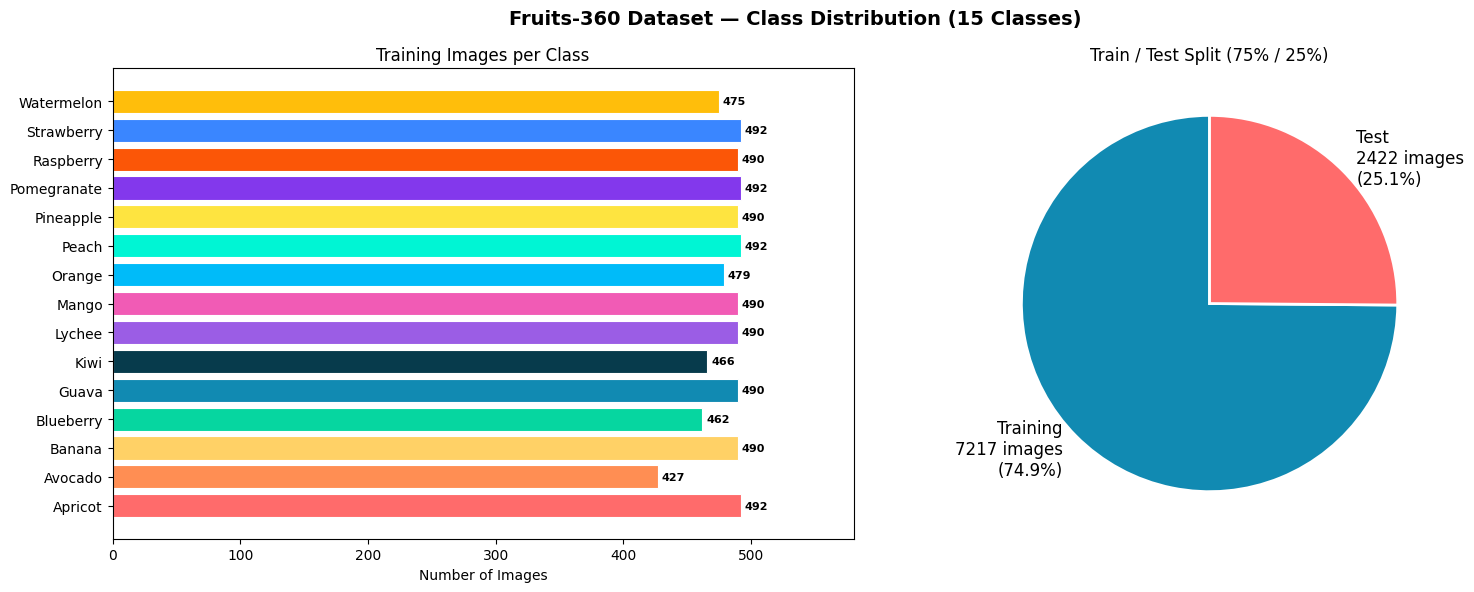

In [4]:
# Define a distinct colour palette for the 15 fruit classes
PALETTE = [
    '#FF6B6B','#FF8E53','#FFD166','#06D6A0','#118AB2',
    '#073B4C','#9B5DE5','#F15BB5','#00BBF9','#00F5D4',
    '#FEE440','#8338EC','#FB5607','#3A86FF','#FFBE0B'
]

# Create a figure with two subplots: bar chart + pie chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fruits-360 Dataset — Class Distribution (15 Classes)',
             fontsize=14, fontweight='bold')

# Bar chart: training image counts per class
fruits = list(train_counts.keys())
counts = list(train_counts.values())
bars = axes[0].barh(fruits, counts, color=PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_title('Training Images per Class', fontsize=12)
axes[0].set_xlabel('Number of Images')
axes[0].set_xlim(0, max(counts) * 1.18)

# Add count labels next to each bar
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 str(v), va='center', fontsize=8, fontweight='bold')

# Pie chart: overall train vs test split
axes[1].pie(
    [total_train, total_test],
    labels=[f'Training\n{total_train} images\n({total_train/(total_train+total_test)*100:.1f}%)',
            f'Test\n{total_test} images\n({total_test/(total_train+total_test)*100:.1f}%)'],
    colors=['#118AB2', '#FF6B6B'],
    startangle=90, wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    textprops={'fontsize': 12}
)
axes[1].set_title('Train / Test Split (75% / 25%)', fontsize=12)

# Final layout and save
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Sample Images from Each of the 15 Classes

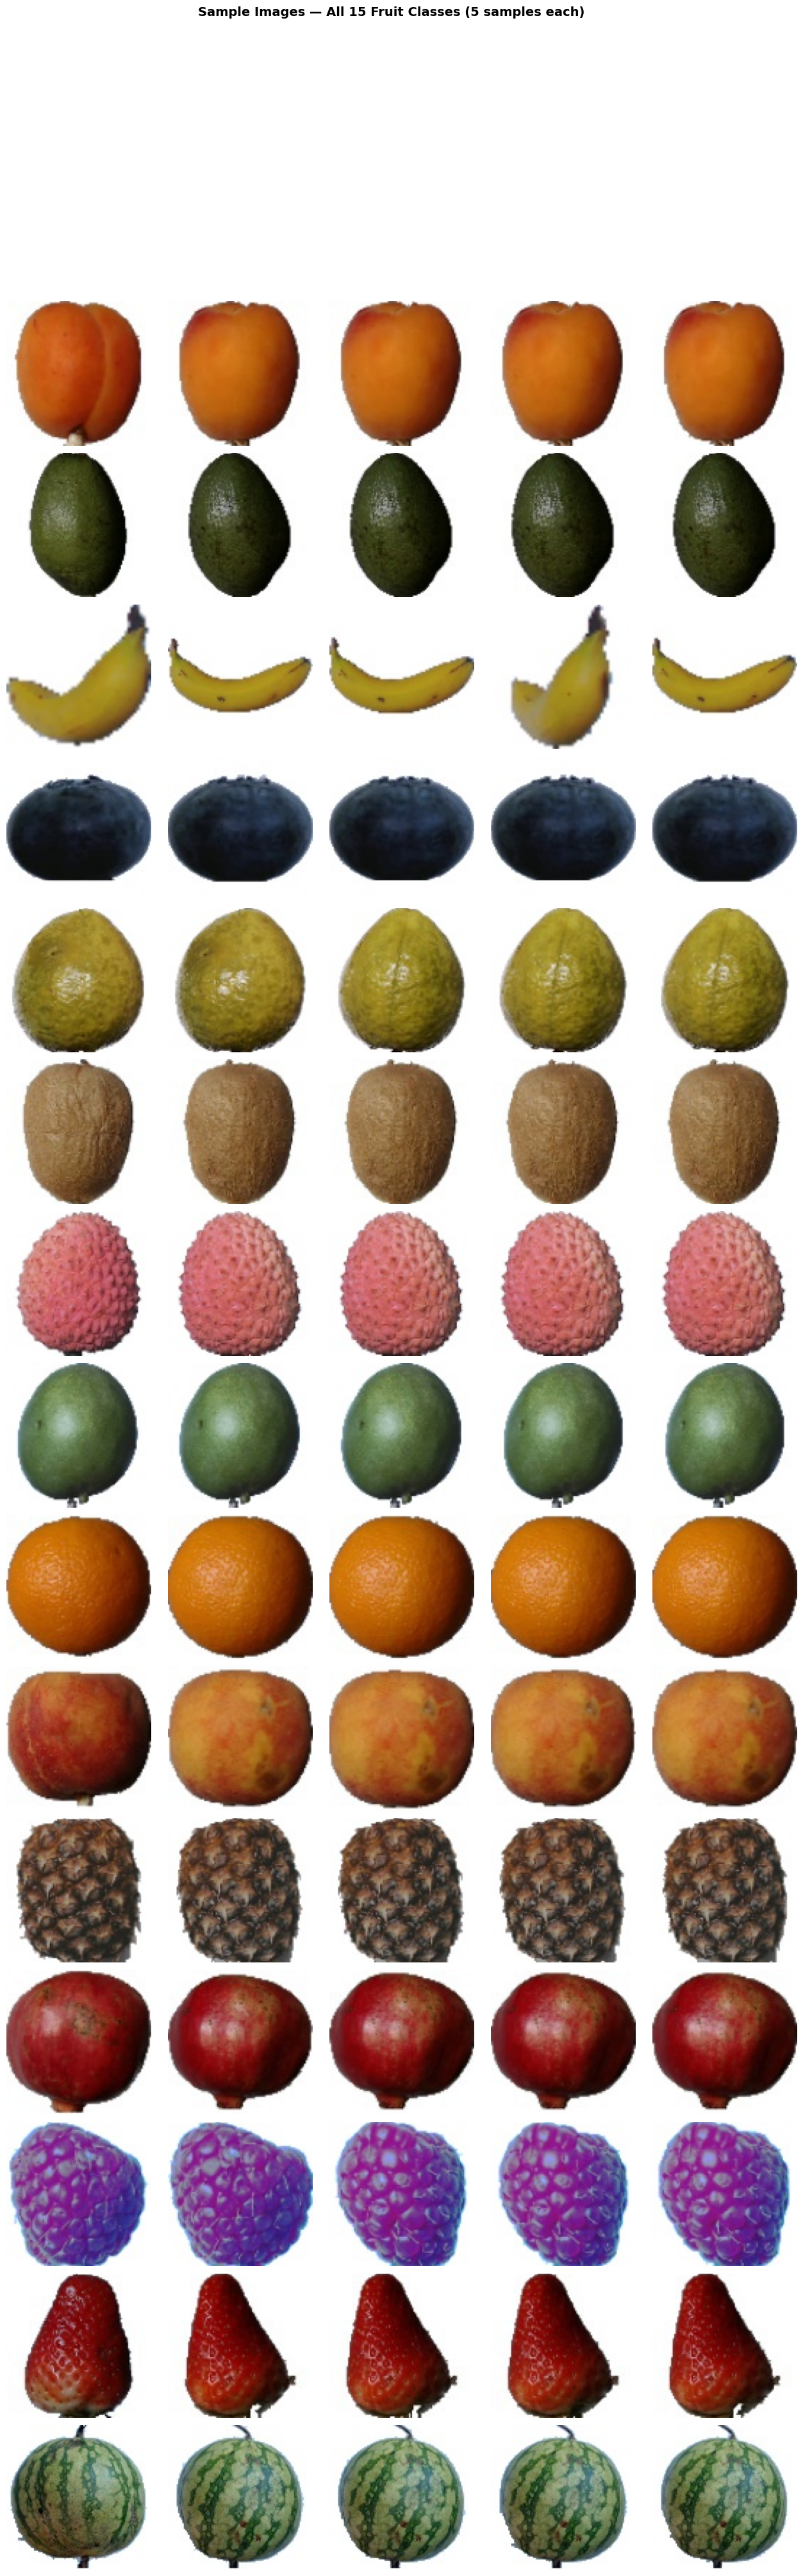

In [5]:
# Create a grid of 15 rows (classes) × 5 columns (samples)
fig, axes = plt.subplots(15, 5, figsize=(16, 46))
fig.suptitle('Sample Images — All 15 Fruit Classes (5 samples each)',
             fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    files    = sorted([f for f in os.listdir(cls_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:5]

    for col_idx, fname in enumerate(files):
        ax = axes[row_idx][col_idx]
        try:
            # Load with Keras (handles all image types reliably)
            img = load_img(os.path.join(cls_path, fname), target_size=(100, 100))
            arr = img_to_array(img).astype('uint8')  # keep as uint8 for imshow
            ax.imshow(arr)
        except Exception as e:
            ax.set_facecolor('#eee')
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=7)
        ax.axis('off')

        # Row label on the leftmost column only
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9, fontweight='bold',
                          color=PALETTE[row_idx], rotation=0,
                          labelpad=60, va='center')

plt.subplots_adjust(left=0.12, hspace=0.05, wspace=0.05)
plt.show()

### 3. Image Properties and Preprocessing Plan

In [6]:
# Pick one sample image from the first fruit class
sample_cls  = CLASS_NAMES[0]  # e.g., 'Apricot'
sample_file = os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0]  # first file in that folder
sample_path = os.path.join(TRAIN_DIR, sample_cls, sample_file)

# Load image with PIL and convert to NumPy array
img_pil = Image.open(sample_path)
img_np  = np.array(img_pil)

# Print image properties
print('=' * 50)
print('  IMAGE PROPERTIES (sample from', sample_cls, ')')
print('=' * 50)
print(f'  Size (W x H)  : {img_pil.size}  — uniform 100x100 across dataset')
print(f'  Mode          : {img_pil.mode}  — RGB, 3 channels')
print(f'  NumPy shape   : {img_np.shape}')  # shape = (height, width, channels)
print(f'  Pixel range   : {img_np.min()} – {img_np.max()}  (uint8)')
print(f'  File format   : JPG')
print(f'  Background    : White/uniform — isolates fruit from background noise')
print()

  IMAGE PROPERTIES (sample from Apricot )
  Size (W x H)  : (100, 100)  — uniform 100x100 across dataset
  Mode          : RGB  — RGB, 3 channels
  NumPy shape   : (100, 100, 3)
  Pixel range   : 0 – 255  (uint8)
  File format   : JPG
  Background    : White/uniform — isolates fruit from background noise



### 4. Data Generators,Train/Validation Split and Augmentation Setup

In [7]:
# Image size for CNN input
IMG_SIZE   = 64       # Baseline & deeper CNN (small, efficient input)
BATCH_SIZE = 32       # Standard batch size for stable training
VAL_SPLIT  = 0.20     # 80% training / 20% validation split

# Training generator with augmentation
# Augmentation is important because Fruits-360 images were captured
# under controlled studio conditions (white background, centered fruit).
# Without augmentation, the model risks overfitting to these idealized images.
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,   # normalize pixels to [0,1]
    validation_split   = VAL_SPLIT,   # split training folder into train/val
    horizontal_flip    = True,        # simulate left/right orientation changes
    rotation_range     = 20,          # fruits may appear rotated in real life
    zoom_range         = 0.15,        # random zoom ±15% to vary scale
    width_shift_range  = 0.10,        # horizontal translation
    height_shift_range = 0.10,        # vertical translation
    shear_range        = 0.10,        # mild shear to simulate perspective
    fill_mode          = 'nearest'    # fill gaps created by transforms
)

# Validation generator — no augmentation, only normalization
# Validation must reflect the true distribution of the dataset.
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT
)

# Flow generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),   # resize to CNN input size
    batch_size=BATCH_SIZE,
    class_mode='categorical',           # multi-class classification
    subset='training',                  # use 80% for training
    seed=SEED,                          # reproducibility
    shuffle=True                        # shuffle for training
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',                # use 20% for validation
    seed=SEED,
    shuffle=False                       # keep validation order fixed
)

# Summary outputs
print(f'Class index mapping : {train_gen.class_indices}')   # maps class names to integer labels
print(f'Training samples    : {train_gen.samples}  (≈80% of total training set)')
print(f'Validation samples  : {val_gen.samples}  (≈20% of total training set)')
print(f'Steps per epoch     : {len(train_gen)}')            # batches per epoch
print(f'Number of classes   : {train_gen.num_classes}')     # should be 15

Found 5777 images belonging to 15 classes.
Found 1440 images belonging to 15 classes.
Class index mapping : {'Apricot': 0, 'Avocado': 1, 'Banana': 2, 'Blueberry': 3, 'Guava': 4, 'Kiwi': 5, 'Lychee': 6, 'Mango': 7, 'Orange': 8, 'Peach': 9, 'Pineapple': 10, 'Pomegranate': 11, 'Raspberry': 12, 'Strawberry': 13, 'Watermelon': 14}
Training samples    : 5777  (≈80% of total training set)
Validation samples  : 1440  (≈20% of total training set)
Steps per epoch     : 181
Number of classes   : 15


### 5. Augmented Image Visualization

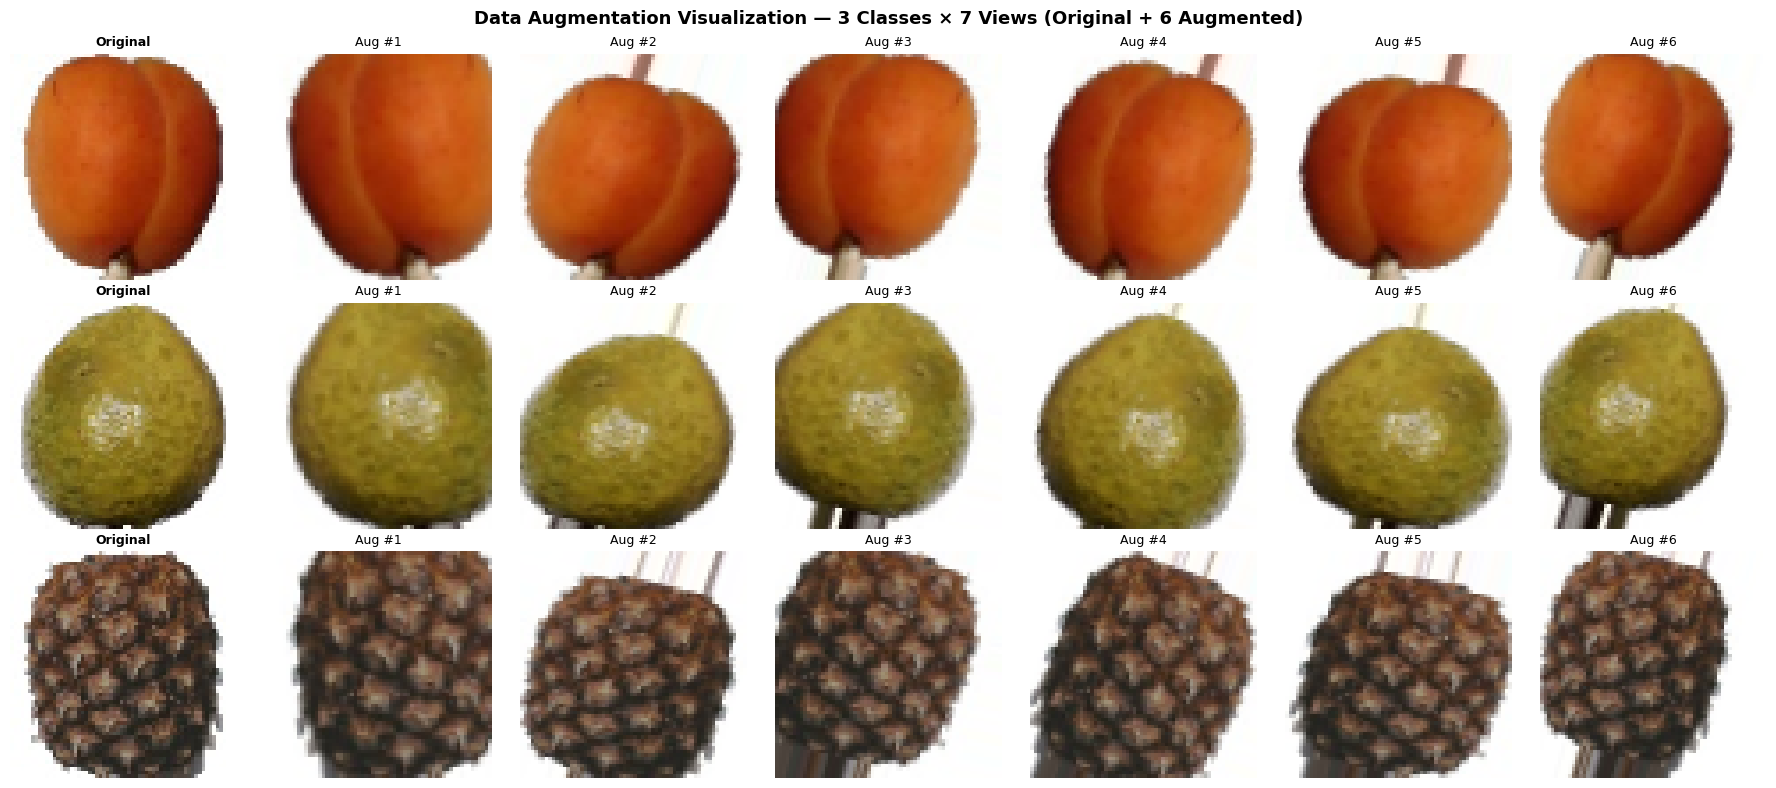

In [8]:
# Augmentation generator
# Adds variability to training images to improve generalisation# Augmentation visualization

aug_display_gen = ImageDataGenerator(
    rescale            = 1.0 / 255,   # applied inside flow → output in [0,1]
    horizontal_flip    = True,
    rotation_range     = 20,
    zoom_range         = 0.15,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    shear_range        = 0.10,
    fill_mode          = 'nearest'
)

showcase_classes = [CLASS_NAMES[0], CLASS_NAMES[4], CLASS_NAMES[10]]

fig, axes = plt.subplots(3, 7, figsize=(18, 8))
fig.suptitle('Data Augmentation Visualization — 3 Classes × 7 Views (Original + 6 Augmented)',
             fontsize=13, fontweight='bold')

for row, cls in enumerate(showcase_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    fname    = sorted([f for f in os.listdir(cls_path)
                       if f.lower().endswith(('.jpg','.jpeg','.png'))])[0]

    # Load as uint8 so aug_gen.rescale=1/255 normalises it correctly
    img_pil = load_img(os.path.join(cls_path, fname), target_size=(IMG_SIZE, IMG_SIZE))
    arr_uint8 = img_to_array(img_pil).astype('uint8')     # shape (64,64,3), values 0–255
    arr_batch = arr_uint8[np.newaxis, ...]                   # shape (1,64,64,3)

    # Column 0 — original image (display normalised copy)
    axes[row][0].imshow(arr_uint8)
    axes[row][0].set_title('Original', fontsize=9, fontweight='bold')
    axes[row][0].set_ylabel(cls, fontsize=10, fontweight='bold',
                             color=PALETTE[CLASS_NAMES.index(cls)],
                             rotation=0, labelpad=55, va='center')
    axes[row][0].axis('off')

    # Columns 1–6 — augmented versions
    aug_iter = aug_display_gen.flow(arr_batch, batch_size=1, seed=SEED)
    for col in range(1, 7):
        aug_img = next(aug_iter)[0]          # float32 in [0,1] after rescale
        aug_img = np.clip(aug_img, 0, 1)     # safety clip to prevent imshow warnings
        axes[row][col].imshow(aug_img)
        axes[row][col].set_title(f'Aug #{col}', fontsize=9)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

## 2.5.2 - Design, Train, and Evaluate a Baseline Model

### 1. Baseline CNN — Model Architecture

In [9]:
def build_baseline_cnn(input_shape=(64, 64, 3), num_classes=15):
    """
    Baseline CNN: 3 convolutional blocks + 3 dense layers + softmax output.
    Filters increase per block (32→64→128) to capture progressively complex features.
    """
    model = models.Sequential(name='Baseline_CNN')

    # Block 1 — low-level features (edges, colour gradients)
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape, name='Conv1'))
    model.add(layers.MaxPooling2D((2,2), name='Pool1'))  # downsample 64→32

    # Block 2 — intermediate features (textures, partial shapes)
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2'))
    model.add(layers.MaxPooling2D((2,2), name='Pool2'))  # downsample 32→16

    # Block 3 — high-level features (fruit contours, surface patterns)
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', name='Conv3'))
    model.add(layers.MaxPooling2D((2,2), name='Pool3'))  # downsample 16→8

    # Flatten feature maps into a single vector
    model.add(layers.Flatten(name='Flatten'))  # 8×8×128 = 8192 values

    # Fully connected layers for classification mapping
    model.add(layers.Dense(256, activation='relu', name='FC1'))
    model.add(layers.Dense(128, activation='relu', name='FC2'))
    model.add(layers.Dense(64,  activation='relu', name='FC3'))

    # Output layer — softmax for 15 fruit classes
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))
    return model

# Build and compile baseline CNN
baseline_model = build_baseline_cnn((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
baseline_model.compile(
    optimizer='adam',                      # adaptive optimizer
    loss='categorical_crossentropy',       # multi-class classification loss
    metrics=['accuracy']                   # track accuracy during training
)

# Print model summary
print('=' * 55)
print('       BASELINE CNN (15 CLASSES) — MODEL SUMMARY')
print('=' * 55)
baseline_model.summary()
print(f'Total Parameters: {baseline_model.count_params():,}')

I0000 00:00:1778401263.060843      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778401263.066779      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


       BASELINE CNN (15 CLASSES) — MODEL SUMMARY


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,783 (8.52 MB)

 Trainable params: 2,232,783 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

Total Parameters: 2,232,783


### 2. Baseline CNN — Model Training

In [10]:
# Define training callbacks
callbacks_baseline = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,      # reduce LR if val_loss plateaus
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_baseline_model.keras',           # save best model based on val_accuracy
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('Training Baseline CNN on 15-class Fruits-360...')
t_start_baseline = time.time()  # record start time

# Train baseline CNN for full epochs
history_baseline = baseline_model.fit(
    train_gen,
    epochs=30,                        # run all 30 epochs
    validation_data=val_gen,          # validation generator
    callbacks=callbacks_baseline,     # apply callbacks (no stopping)
    verbose=1                         # show progress
)

# Calculate training time
baseline_train_time = time.time() - t_start_baseline

# Print training summary
print('\nTraining complete.')
print(f'  Time            : {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)')
print(f'  Epochs run      : {len(history_baseline.history["accuracy"])}')
print(f'  Best val acc    : {max(history_baseline.history["val_accuracy"]):.4f}')

Training Baseline CNN on 15-class Fruits-360...
Epoch 1/30


I0000 00:00:1778401266.531669     144 service.cc:152] XLA service 0x78e3b000e300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778401266.531717     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778401266.531725     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778401266.969789     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/181 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.0590 - loss: 2.7168

I0000 00:00:1778401269.840852     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.4237 - loss: 1.6429
Epoch 1: val_accuracy improved from -inf to 0.99583, saving model to best_baseline_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 32s 151ms/step - accuracy: 0.4251 - loss: 1.6390 - val_accuracy: 0.9958 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9681 - loss: 0.1069
Epoch 2: val_accuracy improved from 0.99583 to 0.99931, saving model to best_baseline_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9682 - loss: 0.1069 - val_accuracy: 0.9993 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9880 - loss: 0.0380
Epoch 3: val_accuracy improved from 0.99931 to 1.00000, saving model to best_baseline_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9881 - loss: 0.0379 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 4/30
181/181 ━━━━━━━━━

### 2.1 Training vs Validation Loss and Accuracy Curves (Baseline CNN)

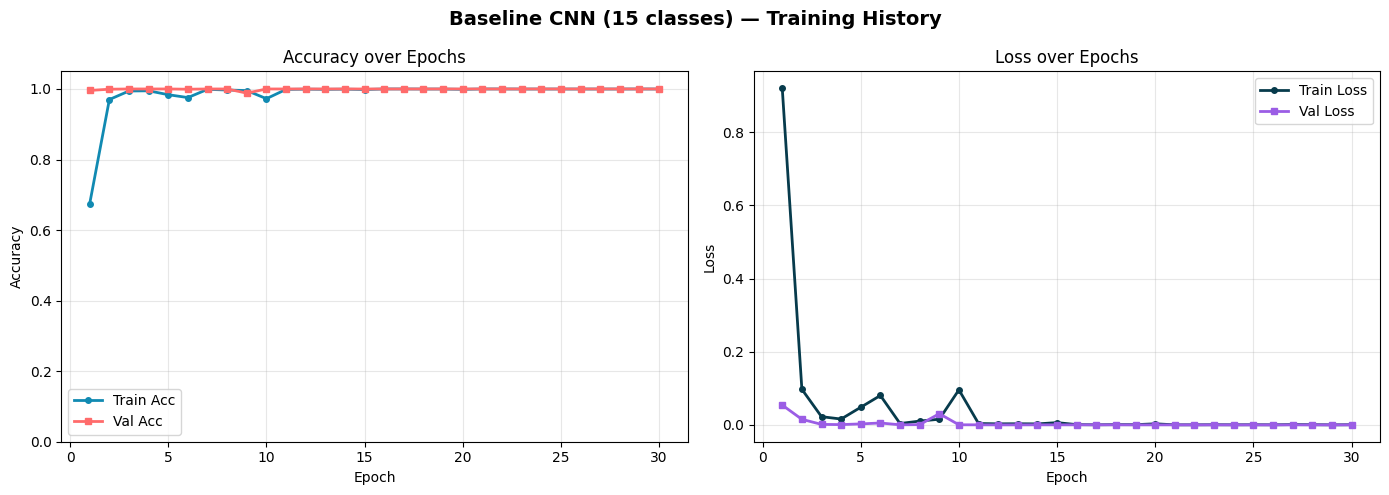

  Best epoch        : 3
  Best val accuracy : 1.0000 (100.00%)
  Train-Val gap     : -0.0002 (Healthy)


In [11]:
def plot_training_history(history, title='Training History'):
    """
    Plot accuracy and loss curves side by side.
    Well-trained model: both train and val curves converge (small gap).
    Overfitting signal: train acc >> val acc with widening gap.
    """
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(epochs, acc,     'o-', color='#118AB2', label='Train Acc', lw=2, ms=4)
    ax1.plot(epochs, val_acc, 's-', color='#FF6B6B', label='Val Acc',   lw=2, ms=4)
    ax1.set_title('Accuracy over Epochs'); ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)
    ax1.set_ylim([0, 1.05])

    ax2.plot(epochs, loss,     'o-', color='#073B4C', label='Train Loss', lw=2, ms=4)
    ax2.plot(epochs, val_loss, 's-', color='#9B5DE5', label='Val Loss',   lw=2, ms=4)
    ax2.set_title('Loss over Epochs'); ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_ep = np.argmax(val_acc) + 1
    gap     = acc[-1] - val_acc[-1]
    print(f'  Best epoch        : {best_ep}')
    print(f'  Best val accuracy : {max(val_acc):.4f} ({max(val_acc)*100:.2f}%)')
    print(f'  Train-Val gap     : {gap:.4f} ({"Overfitting risk" if gap > 0.1 else "Healthy"})')

plot_training_history(history_baseline,
    'Baseline CNN (15 classes) — Training History')

### 3. Baseline CNN — Model Evaluation

  Baseline CNN — 15-CLASS EVALUATION
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000 (macro-avg across 15 classes)
  Recall    : 1.0000  (macro-avg across 15 classes)
  F1-Score  : 1.0000  (macro-avg across 15 classes)

Per-Class Classification Report:
              precision    recall  f1-score   support

     Apricot     1.0000    1.0000    1.0000        98
     Avocado     1.0000    1.0000    1.0000        85
      Banana     1.0000    1.0000    1.0000        98
   Blueberry     1.0000    1.0000    1.0000        92
       Guava     1.0000    1.0000    1.0000        98
        Kiwi     1.0000    1.0000    1.0000        93
      Lychee     1.0000    1.0000    1.0000        98
       Mango     1.0000    1.0000    1.0000        98
      Orange     1.0000    1.0000    1.0000        95
       Peach     1.0000    1.0000    1.0000        98
   Pineapple     1.0000    1.0000    1.0000        98
 Pomegranate     1.0000    1.0000    1.0000        98
   Raspberry     1.0000    1.0000    1.

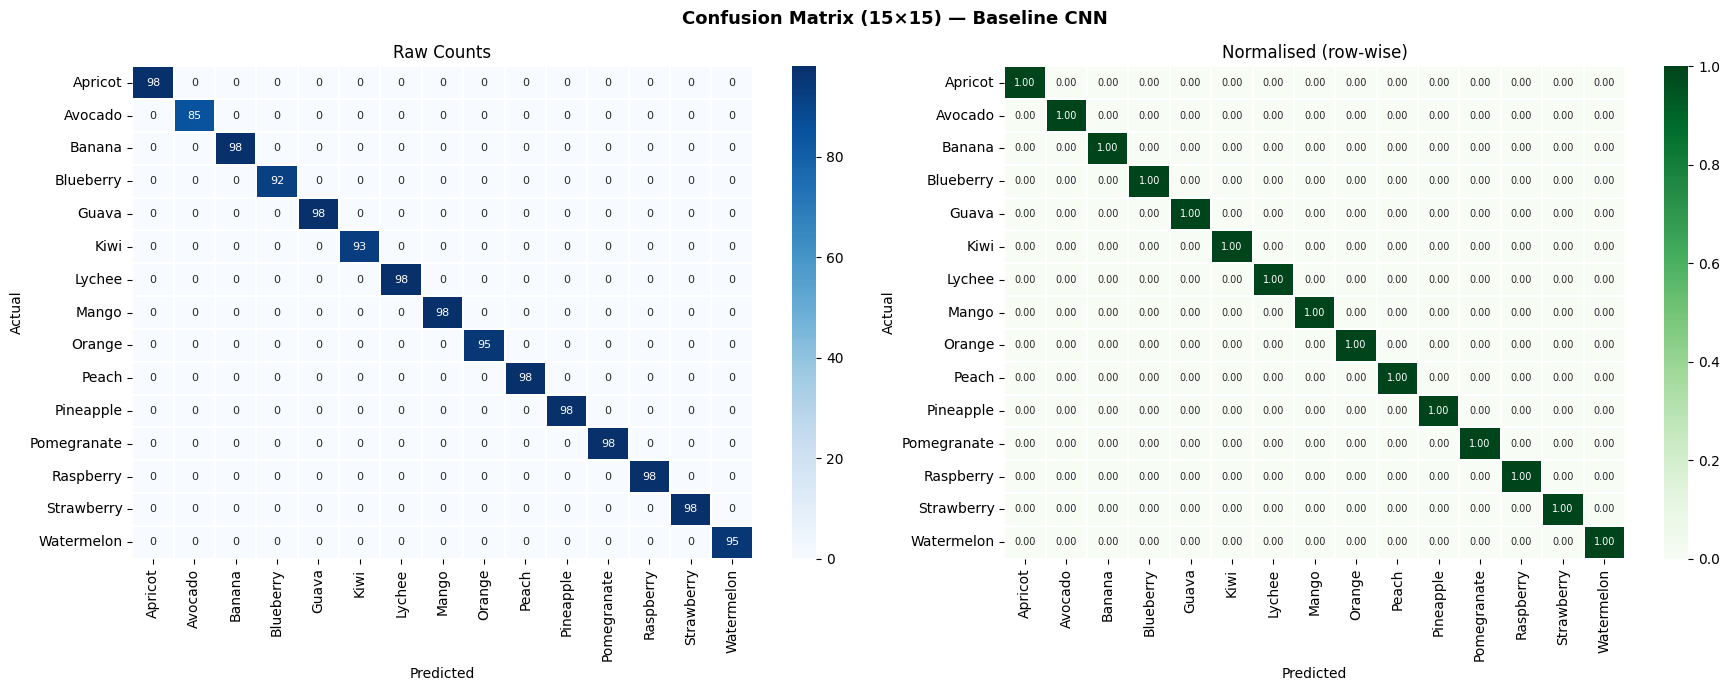

Top confused class pairs (off-diagonal):
    No misclassifications detected — all predictions matched the true labels.
    Diagnostic: y_true length=1440, y_pred length=1440


In [12]:
def evaluate_model(model, generator, class_names, title='Model Evaluation'):
    """
    Evaluation pipeline for 15-class classification:
      Step 1: Predict on validation set
      Step 2: Compute Accuracy, Precision, Recall, F1 (macro-avg)
      Step 3: Print per-class classification report
      Step 4: Plot confusion matrix (raw + normalized)
      Step 5: Highlight top misclassified pairs (with fallback if none)
    """

    # Step 1: Generate predictions on validation set
    generator.reset()  # reset generator to start from first batch
    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)  # predicted labels
    y_true = generator.classes[:len(y_pred)]  # align lengths

    # Step 2: Compute evaluation metrics
    acc  = accuracy_score(y_true, y_pred)   # overall accuracy
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)  # macro precision
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)     # macro recall
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)         # macro F1-score

    # Step 3: Print summary metrics and per-class report
    print('=' * 65)
    print(f'  {title} — 15-CLASS EVALUATION')
    print('=' * 65)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f} (macro-avg across 15 classes)')
    print(f'  Recall    : {rec:.4f}  (macro-avg across 15 classes)')
    print(f'  F1-Score  : {f1:.4f}  (macro-avg across 15 classes)')
    print('=' * 65)
    print('\nPer-Class Classification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=class_names, digits=4))

    # Step 4: Confusion matrix plots (raw counts and normalized percentages)
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix (15×15) — {title}', fontsize=13, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], linewidths=0.3, annot_kws={'size': 8})
    axes[0].set_title('Raw Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], linewidths=0.3, vmin=0, vmax=1, annot_kws={'size': 7})
    axes[1].set_title('Normalised (row-wise)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

    # Step 5: Identify and print top misclassified class pairs
    print('Top confused class pairs (off-diagonal):')
    confused = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i][j] > 0:
                confused.append((cm[i][j], class_names[i], class_names[j]))

    if confused:
        for cnt, true_c, pred_c in sorted(confused, reverse=True)[:5]:
            print(f'    {true_c:>15} misclassified as {pred_c:<15} : {cnt} times')
    else:
        print("    No misclassifications detected — all predictions matched the true labels.")
        # Diagnostic check
        print(f"    Diagnostic: y_true length={len(y_true)}, y_pred length={len(y_pred)}")

    # Return metrics and predictions for reuse
    return acc, prec, rec, f1, y_pred, y_true


# Run evaluation on baseline CNN
baseline_acc, baseline_prec, baseline_rec, baseline_f1, _, _ = \
    evaluate_model(baseline_model, val_gen, CLASS_NAMES, 'Baseline CNN')

### 3.1 Baseline CNN — Inference on Sample Images

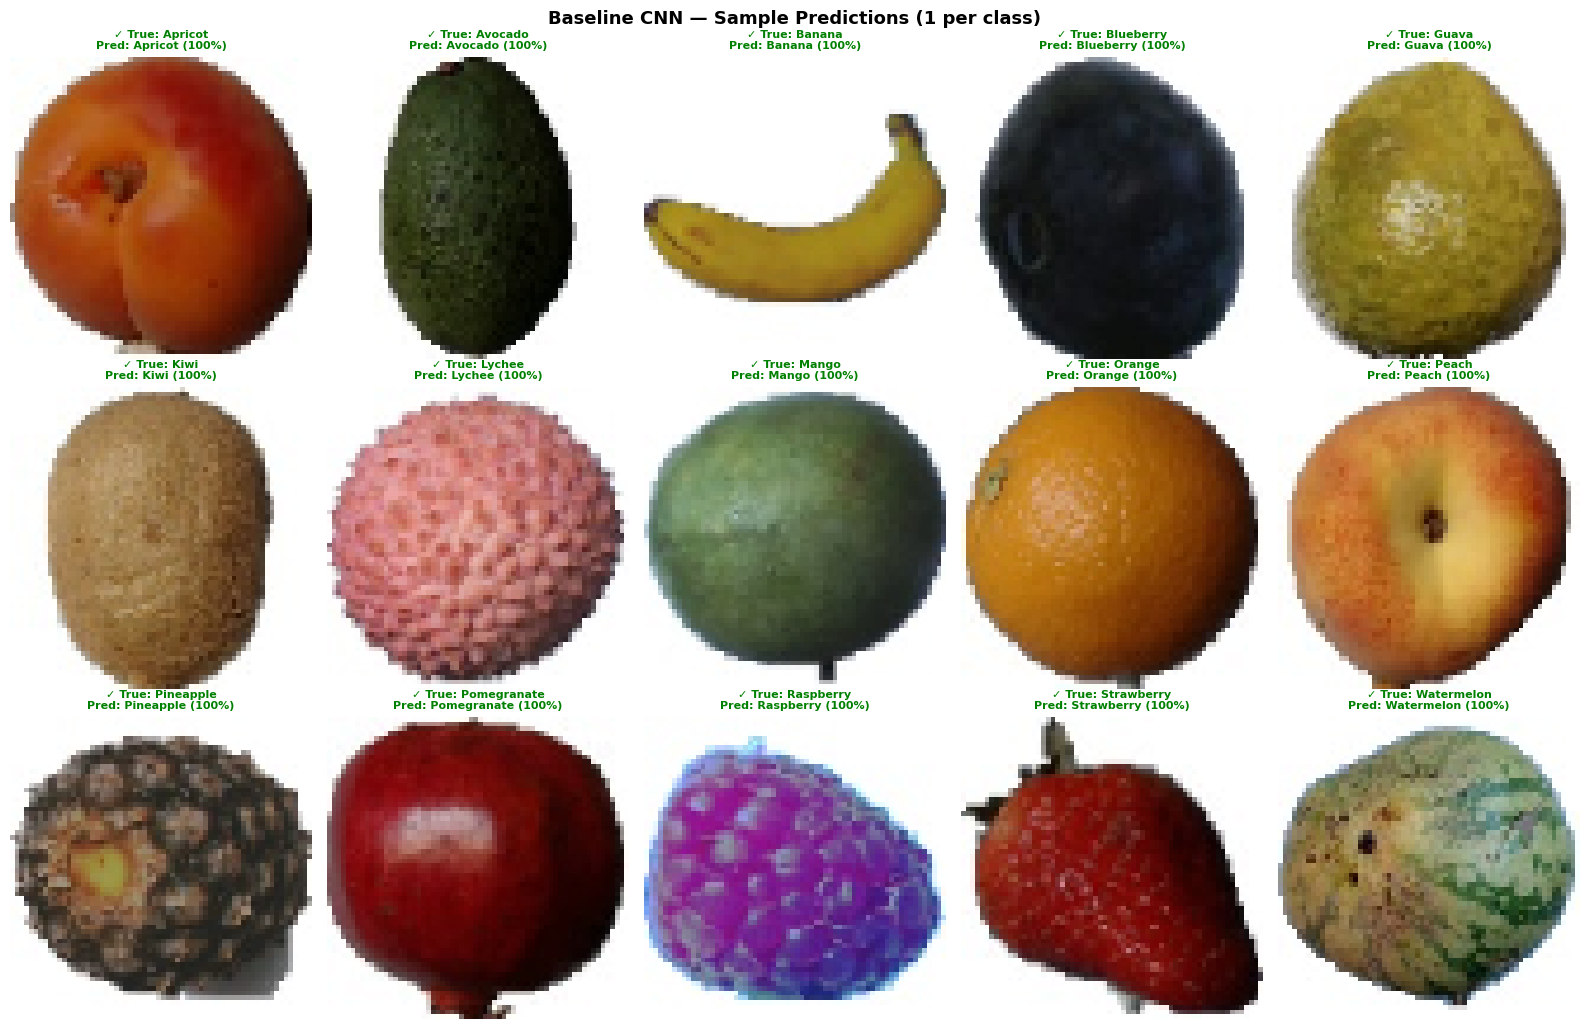

Sample accuracy: 15/15 (100.0%)


In [13]:
def predict_sample_images(model, class_names, data_dir,
                           img_size=64, n_per_class=1, title='Sample Predictions'):
    """
    Display one sample per class (15 images) with ground-truth and prediction.
    Colour-coded: green = correct, red = wrong.
    Confidence score shown for each prediction.
    """

    # Step 1: Collect one random sample image per class
    samples = []
    for cls in class_names:
        cls_path = os.path.join(data_dir, cls)
        files = os.listdir(cls_path)
        pick  = np.random.choice(files, size=1, replace=False)[0]
        samples.append((os.path.join(cls_path, pick), cls))

    # Step 2: Prepare subplot grid for visualization
    cols = 5
    rows = (len(samples) + cols - 1) // cols  # ceil(15/5) = 3
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.5))
    axes = axes.flatten()
    fig.suptitle(f'{title} (1 per class)',
                 fontsize=13, fontweight='bold')

    # Step 3: Run inference and display predictions
    correct, total = 0, 0
    for idx, (img_path, true_cls) in enumerate(samples):
        img  = load_img(img_path, target_size=(img_size, img_size))
        arr  = img_to_array(img) / 255.0
        prob = model.predict(arr[np.newaxis, ...], verbose=0)[0]
        pred_cls = class_names[np.argmax(prob)]
        conf     = prob.max() * 100
        is_correct = pred_cls == true_cls
        correct += int(is_correct)
        total   += 1
        color    = 'green' if is_correct else 'red'
        status   = '✓' if is_correct else '✗'
        axes[idx].imshow(arr)
        axes[idx].set_title(
            f'{status} True: {true_cls}\nPred: {pred_cls} ({conf:.0f}%)',
            fontsize=8, color=color, fontweight='bold')
        axes[idx].axis('off')

    # Step 4: Hide unused subplot axes
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')

    # Step 5: Show results and print sample accuracy
    plt.tight_layout()
    plt.show()
    print(f'Sample accuracy: {correct}/{total} ({correct/total*100:.1f}%)')

# Run sample predictions on baseline CNN
predict_sample_images(baseline_model, CLASS_NAMES, TRAIN_DIR,
                      img_size=IMG_SIZE, title='Baseline CNN — Sample Predictions')

## Section 2.5.3 — Deeper CNN Architecture with Regularization

### 1. Deeper CNN — Model Architecture

In [14]:
def build_deeper_cnn(input_shape=(64,64,3), num_classes=15, dropout_rate=0.4):
    """
    Deeper CNN: 6 Conv blocks (double baseline's 3)
    + BatchNorm after every Conv layer
    + Dropout (0.4) after Dense layers
    """

    model = models.Sequential(name='Deeper_CNN')

    # Step 1: First Conv block (32 filters + BN + ReLU + Pool)
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape, name='D_Conv1'))
    model.add(layers.BatchNormalization(name='D_BN1'))
    model.add(layers.Activation('relu', name='D_ReLU1'))
    model.add(layers.MaxPooling2D((2,2), name='D_Pool1'))  # downsample 64→32

    # Step 2: Second Conv block (64 filters + BN + ReLU + Pool)
    model.add(layers.Conv2D(64, (3,3), padding='same', name='D_Conv2'))
    model.add(layers.BatchNormalization(name='D_BN2'))
    model.add(layers.Activation('relu', name='D_ReLU2'))
    model.add(layers.MaxPooling2D((2,2), name='D_Pool2'))  # downsample 32→16

    # Step 3: Third Conv block (64 filters, no pooling to preserve resolution)
    model.add(layers.Conv2D(64, (3,3), padding='same', name='D_Conv3'))
    model.add(layers.BatchNormalization(name='D_BN3'))
    model.add(layers.Activation('relu', name='D_ReLU3'))

    # Step 4: Fourth Conv block (128 filters + BN + ReLU + Pool)
    model.add(layers.Conv2D(128, (3,3), padding='same', name='D_Conv4'))
    model.add(layers.BatchNormalization(name='D_BN4'))
    model.add(layers.Activation('relu', name='D_ReLU4'))
    model.add(layers.MaxPooling2D((2,2), name='D_Pool4'))  # downsample 16→8

    # Step 5: Fifth Conv block (256 filters, no pooling)
    model.add(layers.Conv2D(256, (3,3), padding='same', name='D_Conv5'))
    model.add(layers.BatchNormalization(name='D_BN5'))
    model.add(layers.Activation('relu', name='D_ReLU5'))

    # Step 6: Sixth Conv block (256 filters + BN + ReLU + Pool)
    model.add(layers.Conv2D(256, (3,3), padding='same', name='D_Conv6'))
    model.add(layers.BatchNormalization(name='D_BN6'))
    model.add(layers.Activation('relu', name='D_ReLU6'))
    model.add(layers.MaxPooling2D((2,2), name='D_Pool6'))  # downsample 8→4

    # Step 7: Flatten feature maps for dense layers
    model.add(layers.Flatten(name='D_Flatten'))  # 4x4x256 = 4096 features

    # Step 8: Dense layers with Dropout regularization
    model.add(layers.Dense(512, activation='relu', name='D_FC1'))
    model.add(layers.Dropout(dropout_rate, name='D_Drop1'))
    model.add(layers.Dense(256, activation='relu', name='D_FC2'))
    model.add(layers.Dropout(dropout_rate, name='D_Drop2'))
    model.add(layers.Dense(128, activation='relu', name='D_FC3'))
    model.add(layers.Dropout(dropout_rate / 2, name='D_Drop3'))

    # Step 9: Output layer for 15-class classification
    model.add(layers.Dense(num_classes, activation='softmax', name='D_Output'))
    return model

# Build and compile deeper CNN
deeper_model = build_deeper_cnn((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES, dropout_rate=0.4)
deeper_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Step 10: Print and analyze model summary
print('=' * 55)
print('   DEEPER CNN (15 CLASSES) — MODEL SUMMARY')
print('=' * 55)
deeper_model.summary()
print(f'Total Parameters   : {deeper_model.count_params():,}')
print(f'Baseline Parameters: {baseline_model.count_params():,}')
print(f'Extra params       : +{deeper_model.count_params()-baseline_model.count_params():,}')

   DEEPER CNN (15 CLASSES) — MODEL SUMMARY


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ D_Conv1 (Conv2D)                │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_BN1 (BatchNormalization)      │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_ReLU1 (Activation)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Pool1 (MaxPooling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Conv2 (Conv2D)                │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_BN2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_ReLU2 (Activation)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Pool2 (MaxPooling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Conv3 (Conv2D)                │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_BN3 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_ReLU3 (Activation)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Conv4 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_BN4 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_ReLU4 (Activation)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Pool4 (MaxPooling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Conv5 (Conv2D)                │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_BN5 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_ReLU5 (Activation)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Conv6 (Conv2D)                │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_BN6 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_ReLU6 (Activation)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Pool6 (MaxPooling2D)          │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Flatten (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_FC1 (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D_Drop1 (Dropout)               │ (None, 512)            │             

 Total params: 3,282,447 (12.52 MB)

 Trainable params: 3,280,847 (12.52 MB)

 Non-trainable params: 1,600 (6.25 KB)

Total Parameters   : 3,282,447
Baseline Parameters: 2,232,783
Extra params       : +1,049,664


### 2. Deeper CNN — Model Training

In [15]:
# Step 1: Define training callbacks for deeper CNN 
callbacks_deeper = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,      # reduce LR by half if val_loss plateaus
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_deeper_model.keras', monitor='val_accuracy',  # save best model by val_accuracy
                    save_best_only=True, verbose=1)
]

# Step 2: Start training and record time
print('Training Deeper CNN on 15-class Fruits-360...')
t_start_deeper = time.time()

# Step 3: Train deeper CNN with callbacks for up to 50 epochs
history_deeper = deeper_model.fit(
    train_gen, epochs=50,
    validation_data=val_gen,
    callbacks=callbacks_deeper, verbose=1
)

# Step 4: Calculate training time and report best validation accuracy
deeper_train_time = time.time() - t_start_deeper
print(f'\nTraining complete.')
print(f'  Time         : {deeper_train_time:.1f}s ({deeper_train_time/60:.1f} min)')
print(f'  Best val acc : {max(history_deeper.history["val_accuracy"]):.4f}')

Training Deeper CNN on 15-class Fruits-360...
Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3869 - loss: 2.2582
Epoch 1: val_accuracy improved from -inf to 0.26319, saving model to best_deeper_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 31s 116ms/step - accuracy: 0.3880 - loss: 2.2529 - val_accuracy: 0.2632 - val_loss: 5.6111 - learning_rate: 0.0010
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8686 - loss: 0.3934
Epoch 2: val_accuracy improved from 0.26319 to 0.94097, saving model to best_deeper_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.8686 - loss: 0.3934 - val_accuracy: 0.9410 - val_loss: 0.2344 - learning_rate: 0.0010
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8950 - loss: 0.3293
Epoch 3: val_accuracy improved from 0.94097 to 0.98472, saving model to best_deeper_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.8950 - loss: 0.3291 - val_accuracy: 0.9847 - val_loss: 0.0570 -

### 2.1 Training Time and Loss Curve Comparison: Baseline vs Deeper CNN


Training Time Comparison
Baseline CNN : 432.8s (7.2 min)
Deeper CNN   : 715.5s (11.9 min)


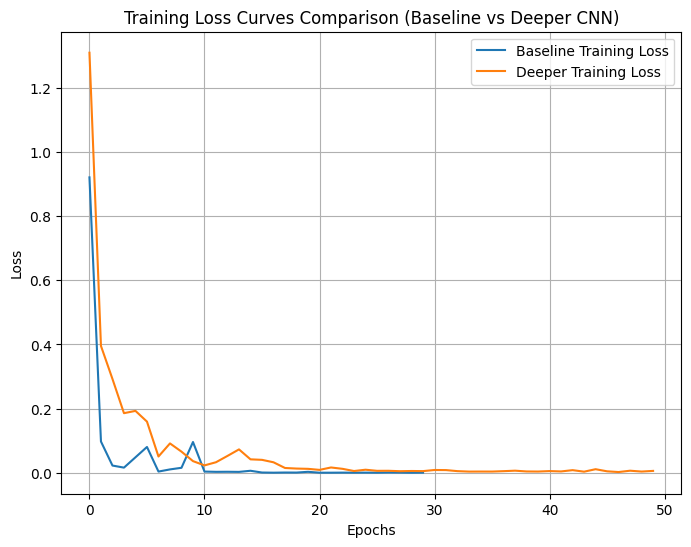

In [16]:
# Compare training time between baseline and deeper CNN
print("\nTraining Time Comparison")
print(f"Baseline CNN : {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)")
print(f"Deeper CNN   : {deeper_train_time:.1f}s ({deeper_train_time/60:.1f} min)")

# Plot training loss curves for baseline and deeper CNN
plt.figure(figsize=(8,6))
plt.plot(history_baseline.history['loss'], label='Baseline Training Loss')
plt.plot(history_deeper.history['loss'], label='Deeper Training Loss')

plt.title('Training Loss Curves Comparison (Baseline vs Deeper CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### 3. Deeper CNN — Model Evaluation

  Deeper CNN — 15-CLASS EVALUATION
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000 (macro-avg across 15 classes)
  Recall    : 1.0000  (macro-avg across 15 classes)
  F1-Score  : 1.0000  (macro-avg across 15 classes)

Per-Class Classification Report:
              precision    recall  f1-score   support

     Apricot     1.0000    1.0000    1.0000        98
     Avocado     1.0000    1.0000    1.0000        85
      Banana     1.0000    1.0000    1.0000        98
   Blueberry     1.0000    1.0000    1.0000        92
       Guava     1.0000    1.0000    1.0000        98
        Kiwi     1.0000    1.0000    1.0000        93
      Lychee     1.0000    1.0000    1.0000        98
       Mango     1.0000    1.0000    1.0000        98
      Orange     1.0000    1.0000    1.0000        95
       Peach     1.0000    1.0000    1.0000        98
   Pineapple     1.0000    1.0000    1.0000        98
 Pomegranate     1.0000    1.0000    1.0000        98
   Raspberry     1.0000    1.0000    1.00

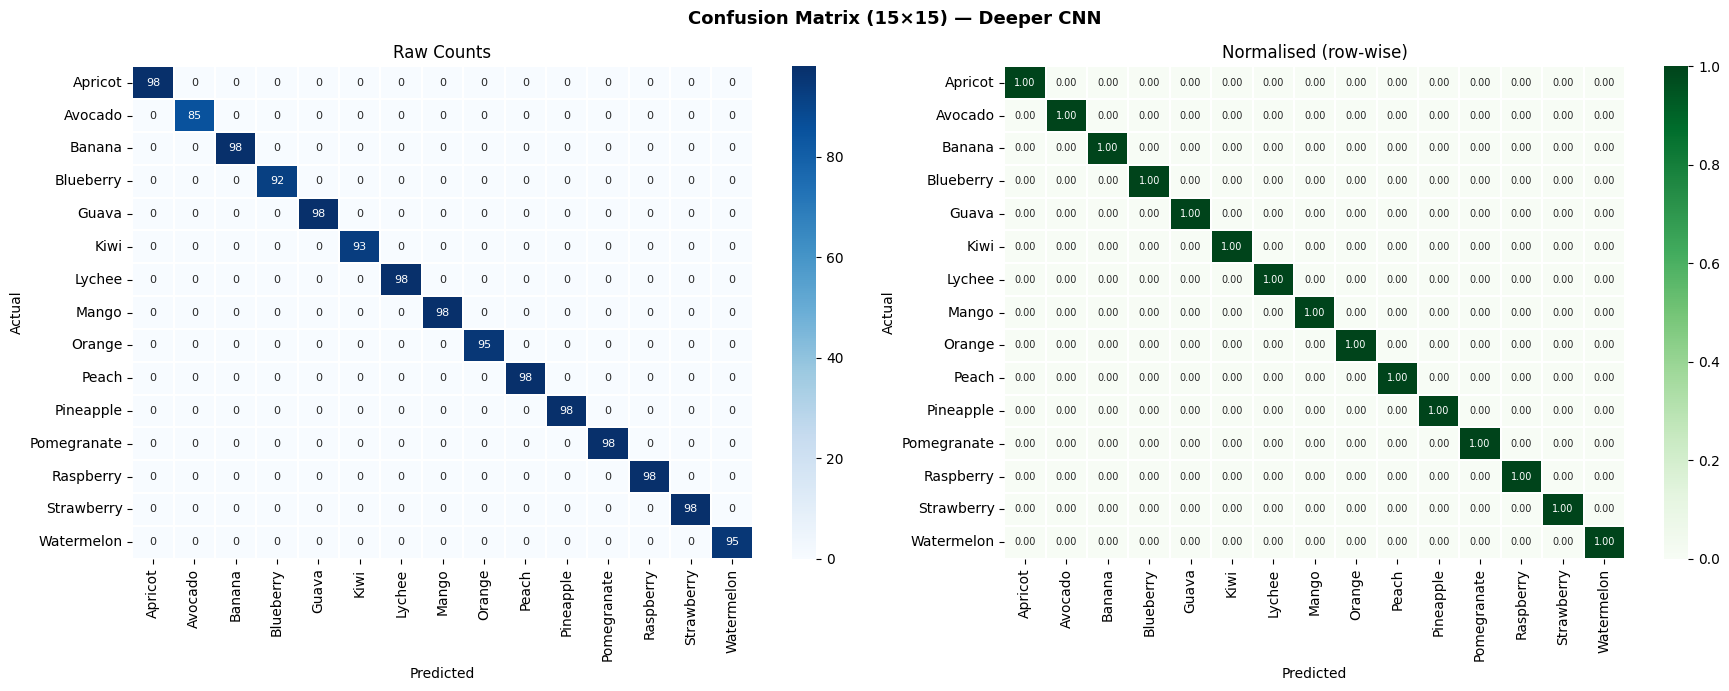

Top confused class pairs (off-diagonal):
    No misclassifications detected — all predictions matched the true labels.
    Diagnostic: y_true length=1440, y_pred length=1440


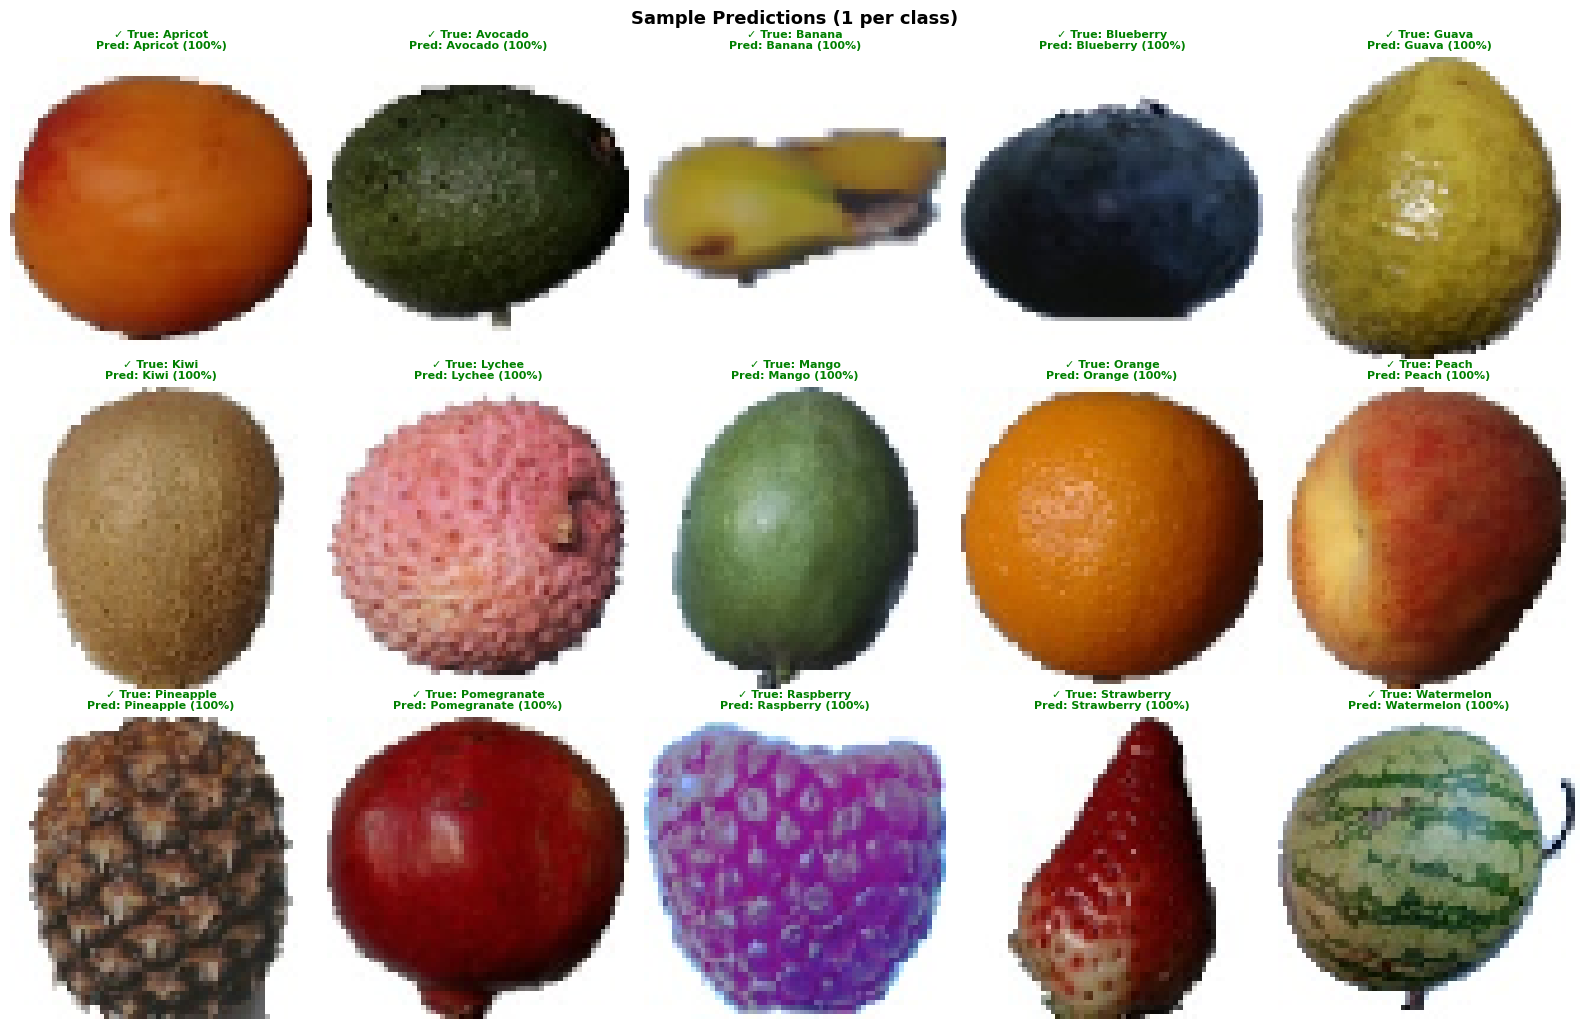

Sample accuracy: 15/15 (100.0%)


In [17]:
# Evaluate deeper CNN on validation set (metrics + confusion matrix)
deeper_acc, deeper_prec, deeper_rec, deeper_f1, _, _ = \
    evaluate_model(deeper_model, val_gen, CLASS_NAMES, 'Deeper CNN')

# Run sample predictions (1 image per class) and visualize results
predict_sample_images(deeper_model, CLASS_NAMES, TRAIN_DIR,
                      img_size=IMG_SIZE)


## Section 2.5.4 — Experimentation and Comparative Analysis

### 1. Baseline vs Deeper CNN — Performance Comparison

  MODEL COMPARISON TABLE — 15-CLASS FRUITS-360
       Model Accuracy Precision Recall F1-Score Parameters Train Time(s)  Epochs Run
Baseline CNN   1.0000    1.0000 1.0000   1.0000  2,232,783         432.8          30
  Deeper CNN   1.0000    1.0000 1.0000   1.0000  3,282,447         715.5          50


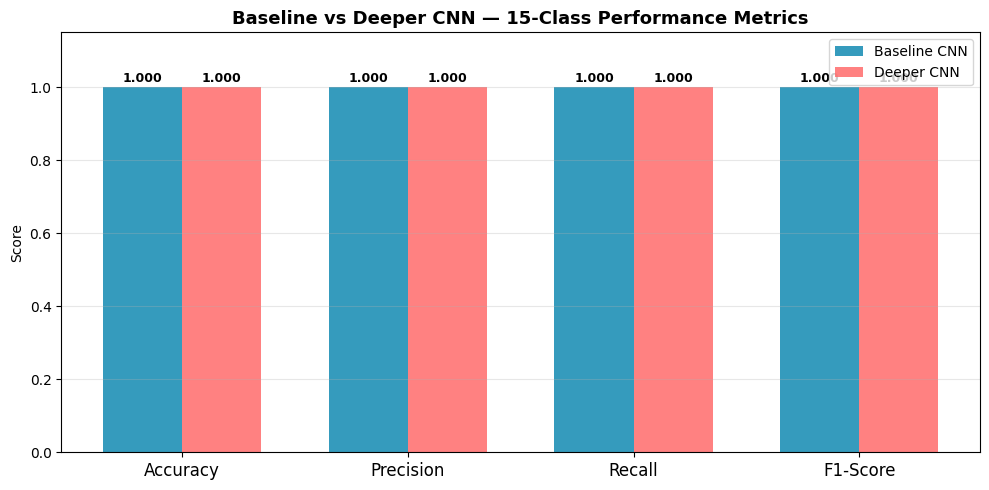

In [18]:
# Build comparison dictionary with key performance indicators
comparison = {
    'Model'        : ['Baseline CNN', 'Deeper CNN'],
    'Accuracy'     : [f'{baseline_acc:.4f}', f'{deeper_acc:.4f}'],
    'Precision'    : [f'{baseline_prec:.4f}', f'{deeper_prec:.4f}'],
    'Recall'       : [f'{baseline_rec:.4f}', f'{deeper_rec:.4f}'],
    'F1-Score'     : [f'{baseline_f1:.4f}', f'{deeper_f1:.4f}'],
    'Parameters'   : [f'{baseline_model.count_params():,}',
                      f'{deeper_model.count_params():,}'],
    'Train Time(s)': [f'{baseline_train_time:.1f}', f'{deeper_train_time:.1f}'],
    'Epochs Run'   : [len(history_baseline.history['accuracy']),
                      len(history_deeper.history['accuracy'])]
}

# Convert to DataFrame for tabular presentation
df_compare = pd.DataFrame(comparison)

# Print formatted comparison table for reporting
print('=' * 75)
print('  MODEL COMPARISON TABLE — 15-CLASS FRUITS-360')
print('=' * 75)
print(df_compare.to_string(index=False))


# Prepare metric values for visualization
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
deeper_vals   = [deeper_acc,   deeper_prec,   deeper_rec,   deeper_f1]
x = np.arange(len(metric_names)); width = 0.35

# Create grouped bar chart comparing baseline vs deeper CNN
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline CNN', color='#118AB2', alpha=0.85)
b2 = ax.bar(x + width/2, deeper_vals,   width, label='Deeper CNN',   color='#FF6B6B', alpha=0.85)

# Annotate bars with metric values for clarity
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Configure chart aesthetics
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Deeper CNN — 15-Class Performance Metrics',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Display chart
plt.tight_layout()
plt.show()

### 2. Computational Efficiency Analysis

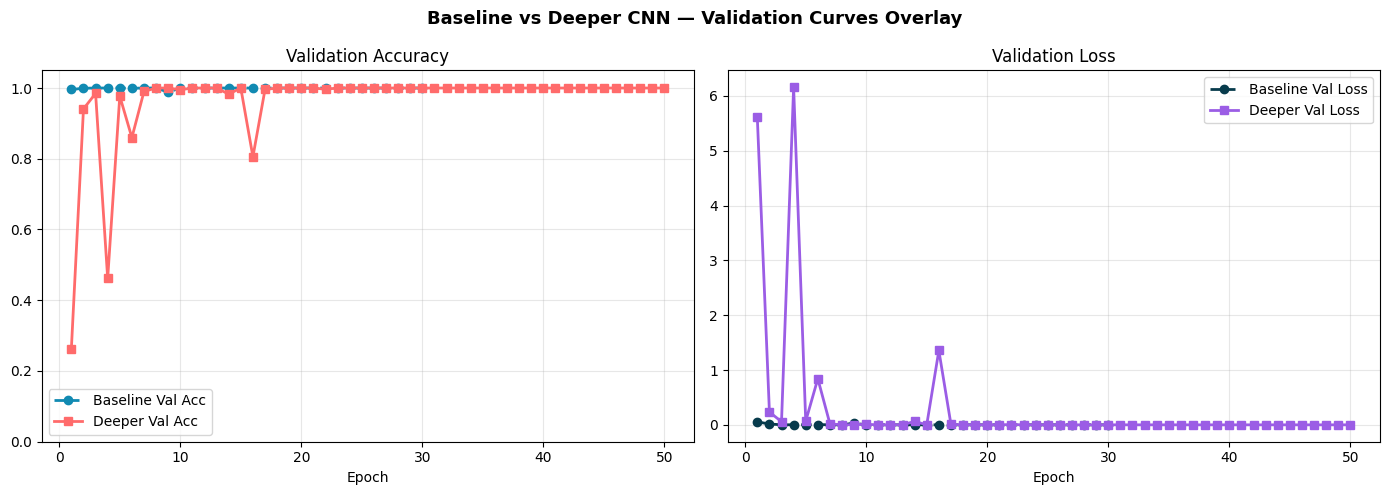

  COMPUTATIONAL EFFICIENCY COMPARISON
  Baseline — Params: 2,232,783  Time: 432.8s  Sec/epoch: 14.43s
  Deeper   — Params: 3,282,447  Time: 715.5s  Sec/epoch: 14.31s
  Overhead: +65.3% compute for deeper model
  Hardware: GPU


In [19]:
# Plot validation accuracy and loss curves for baseline vs deeper CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs Deeper CNN — Validation Curves Overlay',
             fontsize=13, fontweight='bold')

# Define epoch ranges for both models
e_b = range(1, len(history_baseline.history['val_accuracy'])+1)
e_d = range(1, len(history_deeper.history['val_accuracy'])+1)

# Validation accuracy overlay
ax1.plot(e_b, history_baseline.history['val_accuracy'], 'o--', color='#118AB2',
         label='Baseline Val Acc', lw=2)
ax1.plot(e_d, history_deeper.history['val_accuracy'], 's-',  color='#FF6B6B',
         label='Deeper Val Acc', lw=2)
ax1.set_title('Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Validation loss overlay
ax2.plot(e_b, history_baseline.history['val_loss'], 'o--', color='#073B4C',
         label='Baseline Val Loss', lw=2)
ax2.plot(e_d, history_deeper.history['val_loss'],   's-',  color='#9B5DE5',
         label='Deeper Val Loss', lw=2)
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

# Display overlay figure
plt.tight_layout()
plt.show()


# Calculate relative computational overhead of deeper CNN
overhead = (deeper_train_time - baseline_train_time) / baseline_train_time * 100

# Print efficiency comparison including parameters, time, and per-epoch cost
print('=' * 60)
print('  COMPUTATIONAL EFFICIENCY COMPARISON')
print('=' * 60)
print(f'  Baseline — Params: {baseline_model.count_params():,}  '
      f'Time: {baseline_train_time:.1f}s  '
      f'Sec/epoch: {baseline_train_time/len(history_baseline.history["accuracy"]):.2f}s')
print(f'  Deeper   — Params: {deeper_model.count_params():,}  '
      f'Time: {deeper_train_time:.1f}s  '   # ✅ fixed: variable added before colon
      f'Sec/epoch: {deeper_train_time/len(history_deeper.history["accuracy"]):.2f}s')
print(f'  Overhead: +{overhead:.1f}% compute for deeper model')

# Identify hardware context for reproducibility
hw = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU — recommend Colab GPU'
print(f'  Hardware: {hw}')

### 3. Optimizer Analysis: Adam vs SGD

Training Deeper CNN with SGD (15 classes)...
Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 26s 106ms/step - accuracy: 0.4445 - loss: 1.7650 - val_accuracy: 0.3910 - val_loss: 5.3817 - learning_rate: 0.0100
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.8312 - loss: 0.4745 - val_accuracy: 0.5319 - val_loss: 2.7868 - learning_rate: 0.0100
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9046 - loss: 0.3047 - val_accuracy: 0.7764 - val_loss: 0.7785 - learning_rate: 0.0100
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9297 - loss: 0.2419 - val_accuracy: 0.9486 - val_loss: 0.2275 - learning_rate: 0.0100
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9435 - loss: 0.1936 - val_accuracy: 0.9243 - val_loss: 0.4663 - learning_rate: 0.0100
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9623 - loss: 0.1435 - val_accuracy: 0.8139 - val_loss: 1.3165 - learning_rate: 0.0100
Epoch 7/30
181/181 ━━━━━━━━━━━

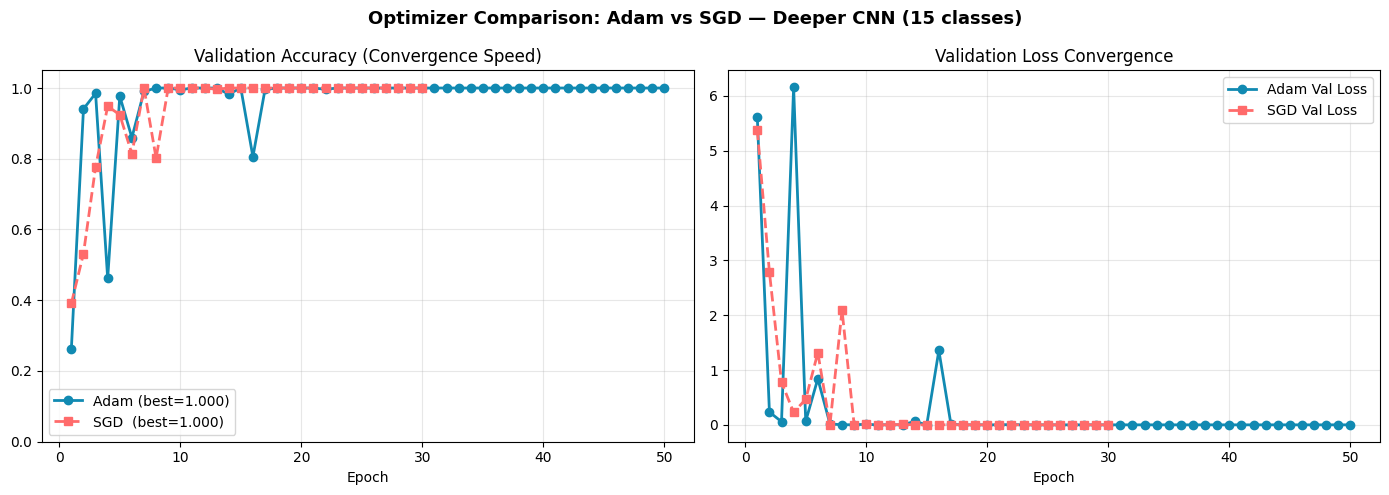

In [20]:
# Build deeper CNN with SGD optimizer for comparative analysis
model_sgd = build_deeper_cnn((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
model_sgd.compile(
    optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Train deeper CNN using SGD and record training time
print('Training Deeper CNN with SGD (15 classes)...')
t_start_sgd = time.time()
history_sgd = model_sgd.fit(
    train_gen, epochs=30, validation_data=val_gen,
    callbacks=[
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ], verbose=1
)
sgd_time = time.time() - t_start_sgd

# Evaluate SGD model on validation set (accuracy + F1-score)
val_gen.reset()
sgd_preds = np.argmax(model_sgd.predict(val_gen, verbose=0), axis=1)
sgd_acc   = accuracy_score(val_gen.classes, sgd_preds)
sgd_f1    = f1_score(val_gen.classes, sgd_preds, average='macro', zero_division=0)

# Print comparative results for Adam vs SGD
print(f'\nAdam — Val Acc: {deeper_acc:.4f} | F1: {deeper_f1:.4f} | Time: {deeper_train_time:.1f}s')
print(f'SGD  — Val Acc: {sgd_acc:.4f} | F1: {sgd_f1:.4f} | Time: {sgd_time:.1f}s')

# Plot validation accuracy and loss curves for Adam vs SGD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: Adam vs SGD — Deeper CNN (15 classes)',
             fontsize=13, fontweight='bold')

# Validation accuracy convergence
e_adam = range(1, len(history_deeper.history['val_accuracy'])+1)
e_sgd  = range(1, len(history_sgd.history['val_accuracy'])+1)
ax1.plot(e_adam, history_deeper.history['val_accuracy'], 'o-', color='#118AB2',
         label=f'Adam (best={max(history_deeper.history["val_accuracy"]):.3f})', lw=2)
ax1.plot(e_sgd,  history_sgd.history['val_accuracy'],   's--', color='#FF6B6B',
         label=f'SGD  (best={max(history_sgd.history["val_accuracy"]):.3f})',  lw=2)
ax1.set_title('Validation Accuracy (Convergence Speed)')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Validation loss convergence
ax2.plot(e_adam, history_deeper.history['val_loss'], 'o-',  color='#118AB2',
         label='Adam Val Loss', lw=2)
ax2.plot(e_sgd,  history_sgd.history['val_loss'],   's--', color='#FF6B6B',
         label='SGD Val Loss',  lw=2)
ax2.set_title('Validation Loss Convergence')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

# Display optimizer comparison plots
plt.tight_layout()
plt.show()

### 4. Ablation Study — Effect of Dropout

Ablation Study: Training WITHOUT Dropout (15 classes)...
Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 26s 98ms/step - accuracy: 0.5925 - loss: 1.5653 - val_accuracy: 0.1236 - val_loss: 10.4604
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9118 - loss: 0.2767 - val_accuracy: 0.3896 - val_loss: 5.1345
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9515 - loss: 0.1596 - val_accuracy: 0.7479 - val_loss: 1.9713
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9748 - loss: 0.0915 - val_accuracy: 0.9632 - val_loss: 0.0962
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9802 - loss: 0.0551 - val_accuracy: 0.8694 - val_loss: 0.8316
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9779 - loss: 0.0722 - val_accuracy: 0.9986 - val_loss: 0.0132
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9763 - loss: 0.0842 - val_accuracy: 0.4549 - val_loss: 12.2849
Epoch 8/30
181/181 ━━━━━━━━━━━━

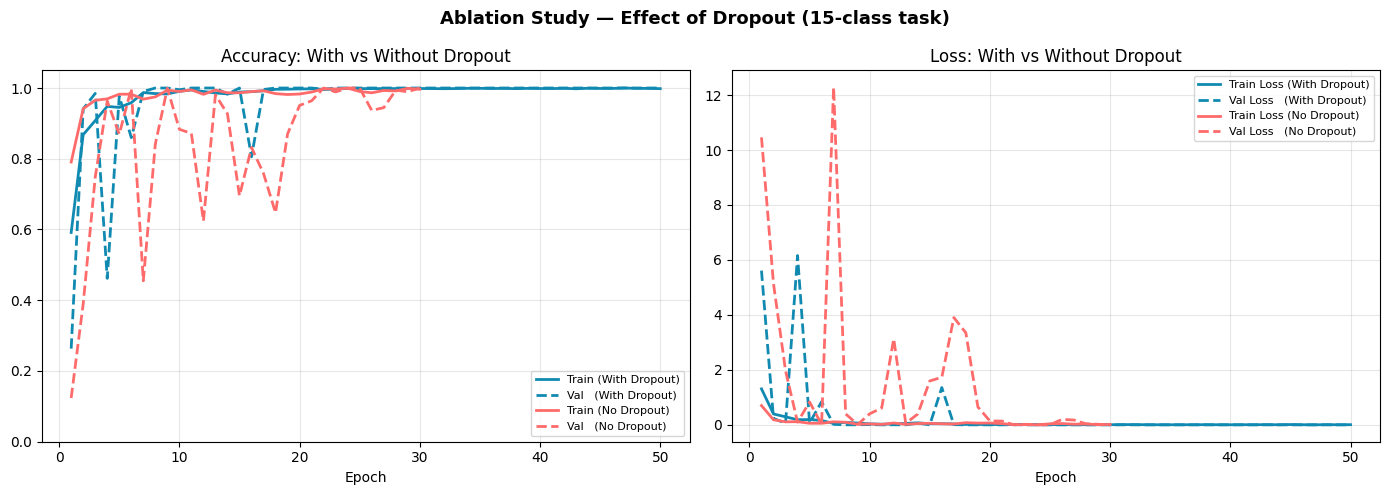

In [21]:
# Build deeper CNN with dropout disabled for ablation study
model_no_dropout = build_deeper_cnn((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES,
                                     dropout_rate=0.0)  # Dropout disabled
model_no_dropout.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Train deeper CNN without dropout
print('Ablation Study: Training WITHOUT Dropout (15 classes)...')
history_no_drop = model_no_dropout.fit(
    train_gen, epochs=30, validation_data=val_gen, verbose=1
)

# Evaluate model without dropout on validation set
val_gen.reset()
nd_preds = np.argmax(model_no_dropout.predict(val_gen, verbose=0), axis=1)
nd_acc   = accuracy_score(val_gen.classes, nd_preds)
nd_f1    = f1_score(val_gen.classes, nd_preds, average='macro', zero_division=0)

# Print comparative results for dropout vs no dropout
print(f'With Dropout    — Val Acc: {deeper_acc:.4f} | F1: {deeper_f1:.4f}')
print(f'Without Dropout — Val Acc: {nd_acc:.4f} | F1: {nd_f1:.4f}')
delta = deeper_acc - nd_acc
print(f'Dropout benefit : {"+" if delta>=0 else ""}{delta:.4f} accuracy points')
print('(Expected: larger benefit than 5-class task due to similar-looking fruit pairs)')

# Plot accuracy and loss curves for dropout vs no dropout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study — Effect of Dropout (15-class task)',
             fontsize=13, fontweight='bold')

# Accuracy comparison
e_d  = range(1, len(history_deeper.history['accuracy'])+1)
e_nd = range(1, len(history_no_drop.history['accuracy'])+1)
ax1.plot(e_d,  history_deeper.history['accuracy'],     '-',  color='#118AB2',
         label='Train (With Dropout)', lw=2)
ax1.plot(e_d,  history_deeper.history['val_accuracy'], '--', color='#118AB2',
         label='Val   (With Dropout)', lw=2)
ax1.plot(e_nd, history_no_drop.history['accuracy'],    '-',  color='#FF6B6B',
         label='Train (No Dropout)',  lw=2)
ax1.plot(e_nd, history_no_drop.history['val_accuracy'],'--', color='#FF6B6B',
         label='Val   (No Dropout)',  lw=2)
ax1.set_title('Accuracy: With vs Without Dropout')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_ylim([0,1.05])

# Loss comparison
ax2.plot(e_d,  history_deeper.history['loss'],         '-',  color='#118AB2',
         label='Train Loss (With Dropout)', lw=2)
ax2.plot(e_d,  history_deeper.history['val_loss'],     '--', color='#118AB2',
         label='Val Loss   (With Dropout)', lw=2)
ax2.plot(e_nd, history_no_drop.history['loss'],        '-',  color='#FF6B6B',
         label='Train Loss (No Dropout)', lw=2)
ax2.plot(e_nd, history_no_drop.history['val_loss'],    '--', color='#FF6B6B',
         label='Val Loss   (No Dropout)', lw=2)
ax2.set_title('Loss: With vs Without Dropout')
ax2.set_xlabel('Epoch')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Display ablation study plots
plt.tight_layout()
plt.show()

# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

*(Section 2.6)*

## Section 2.6.1 — Loading and Adapting a Pre-Trained Model (MobileNetV2)

In [22]:
IMG_SIZE_TL = 96   # MobileNetV2 minimum input size; close to native 100x100 images
# Using 96x96 is memory-efficient compared to 224x224 (VGG default)
# Minimizes distortion by avoiding significant upscaling

# Training data generator with MobileNetV2 preprocessing and augmentation
tl_train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,  # scales pixels to [-1, 1]
    validation_split       = 0.20,                  # 80/20 train-validation split
    horizontal_flip        = True,                  # augmentation: mirror images
    rotation_range         = 15,                    # augmentation: small rotations
    zoom_range             = 0.10,                  # augmentation: zoom in/out
    width_shift_range      = 0.10,                  # augmentation: horizontal shifts
    height_shift_range     = 0.10                   # augmentation: vertical shifts
)

# Validation data generator (no augmentation, only preprocessing)
tl_val_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = 0.20
)

# Training generator: loads images, applies augmentation, shuffles batches
tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True
)

# Validation generator: loads images, applies preprocessing, no shuffling
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)

# Dataset summary for reporting
print(f'MobileNetV2 Input size   : {IMG_SIZE_TL}x{IMG_SIZE_TL}x3')
print(f'TL Training samples      : {tl_train_gen.samples}')
print(f'TL Validation samples    : {tl_val_gen.samples}')
print(f'Number of classes        : {tl_train_gen.num_classes}')
print('Preprocessing            : mobilenet_preprocess → scales pixels to [-1, 1]')

Found 5777 images belonging to 15 classes.
Found 1440 images belonging to 15 classes.
MobileNetV2 Input size   : 96x96x3
TL Training samples      : 5777
TL Validation samples    : 1440
Number of classes        : 15
Preprocessing            : mobilenet_preprocess → scales pixels to [-1, 1]


## Section 2.6.2 — Model Training and Fine-Tuning

### 1. Feature Extraction — Frozen MobileNetV2 Base

In [23]:
def build_mobilenet_feature_extractor(num_classes=15, img_size=96):
    """
    MobileNetV2 Feature Extraction Strategy:
    - Load MobileNetV2 pretrained on ImageNet (exclude original classifier)
    - Freeze all convolutional layers to retain learned representations
    - Add custom dense layers for 15-class Fruits-360 classification
    """

    # Load pretrained MobileNetV2 without top classification layers
    base_model = MobileNetV2(
        weights     = 'imagenet',
        include_top = False,                    # remove 1000-class ImageNet head
        input_shape = (img_size, img_size, 3)
    )
    base_model.trainable = False               # freeze convolutional base

    # Report frozen layers and trainable parameters for reproducibility
    frozen = sum(1 for l in base_model.layers if not l.trainable)
    print(f'MobileNetV2 base layers  : {len(base_model.layers)}')
    print(f'Frozen layers            : {frozen}')
    print(f'Trainable params (base)  : {sum(v.numpy().size for v in base_model.trainable_variables)}')

    # Build custom classification head
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)     # BN layers in inference mode
    x = layers.GlobalAveragePooling2D()(x)    # reduce spatial dimensions
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # final 15-class output

    # Construct full model with frozen base + new head
    model = keras.Model(inputs, outputs, name='MobileNetV2_FeatureExtractor')
    return model, base_model


# Instantiate feature extractor model and compile for training
mobilenet_fe, mobilenet_base = build_mobilenet_feature_extractor(NUM_CLASSES, IMG_SIZE_TL)
mobilenet_fe.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Print model summary for documentation
print('\n' + '='*55)
print('  MOBILENETV2 FEATURE EXTRACTOR — MODEL SUMMARY')
print('='*55)
mobilenet_fe.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 base layers  : 154
Frozen layers            : 154
Trainable params (base)  : 0

  MOBILENETV2 FEATURE EXTRACTOR — MODEL SUMMARY


Model: "MobileNetV2_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,751 (10.00 MB)

 Trainable params: 362,767 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 1.1 Training the MobileNetV2 Feature Extractor

In [24]:
print('Training MobileNetV2 Feature Extractor (frozen base, 15 classes)...')
t_start_fe = time.time()

history_fe = mobilenet_fe.fit(
    tl_train_gen, epochs=20,
    validation_data=tl_val_gen,
    callbacks=[
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1),
        ModelCheckpoint('best_mobilenet_fe.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ], verbose=1
)
t_fe_time = time.time() - t_start_fe

print(f'\nFeature Extraction complete.')
print(f'  Time: {t_fe_time:.1f}s | Best Val Acc: {max(history_fe.history["val_accuracy"]):.4f}')

Training MobileNetV2 Feature Extractor (frozen base, 15 classes)...
Epoch 1/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7741 - loss: 0.7937
Epoch 1: val_accuracy improved from -inf to 0.97986, saving model to best_mobilenet_fe.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 50s 190ms/step - accuracy: 0.7749 - loss: 0.7909 - val_accuracy: 0.9799 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9943 - loss: 0.0239
Epoch 2: val_accuracy improved from 0.97986 to 1.00000, saving model to best_mobilenet_fe.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.9943 - loss: 0.0238 - val_accuracy: 1.0000 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9985 - loss: 0.0081
Epoch 3: val_accuracy did not improve from 1.00000
181/181 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.9985 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0031 - learning_rate: 0.0

### 1.2 Fine-Tuning — Unfreezing Last MobileNetV2 Blocks

In [25]:
def fine_tune_mobilenet(base_model, full_model, unfreeze_from_layer=100):
    """
    MobileNetV2 Fine-Tuning Strategy:
    - Unfreeze layers from index `unfreeze_from_layer` onward
    - Keep earlier layers frozen (low-level universal features: edges, textures)
    - Recompile with very low LR (1e-5) to avoid catastrophic forgetting

    Rationale:
    - MobileNetV2 has ~154 layers; unfreezing from ~100 exposes deeper residual blocks
      that capture fruit-specific textures and shapes.
    - Fine-tuning adapts pretrained ImageNet features to Fruits-360 while preserving
      general low-level representations.
    """
    base_model.trainable = True

    # Freeze all layers before the unfreeze point
    for layer in base_model.layers[:unfreeze_from_layer]:
        layer.trainable = False

    # Report trainable vs frozen layers for reproducibility
    trainable = sum(1 for l in base_model.layers if l.trainable)
    frozen    = sum(1 for l in base_model.layers if not l.trainable)
    print(f'Unfreezing from layer index : {unfreeze_from_layer}')
    print(f'Total MobileNetV2 layers    : {len(base_model.layers)}')
    print(f'Now trainable               : {trainable} | Still frozen: {frozen}')

    # Recompile with very small LR — prevents catastrophic forgetting of ImageNet weights
    full_model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than FE
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return full_model


# Apply fine-tuning strategy to MobileNetV2
mobilenet_ft = fine_tune_mobilenet(mobilenet_base, mobilenet_fe, unfreeze_from_layer=100)

print('\nFine-Tuning MobileNetV2 on 15-class Fruits-360...')
t_start_ft = time.time()

# Train fine-tuned model with callbacks for stability and best model preservation
history_ft = mobilenet_ft.fit(
    tl_train_gen, epochs=20,
    validation_data=tl_val_gen,
    callbacks=[
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1),              # adaptive LR scheduling
        ModelCheckpoint('best_mobilenet_ft.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)        # save best model weights
    ], verbose=1
)
t_ft_time = time.time() - t_start_ft

# Report fine-tuning results
print(f'\nFine-Tuning complete.')
print(f'  Time: {t_ft_time:.1f}s | Best Val Acc: {max(history_ft.history["val_accuracy"]):.4f}')

Unfreezing from layer index : 100
Total MobileNetV2 layers    : 154
Now trainable               : 54 | Still frozen: 100

Fine-Tuning MobileNetV2 on 15-class Fruits-360...
Epoch 1/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6832 - loss: 1.3782
Epoch 1: val_accuracy improved from -inf to 0.99722, saving model to best_mobilenet_ft.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 55s 186ms/step - accuracy: 0.6838 - loss: 1.3750 - val_accuracy: 0.9972 - val_loss: 0.0108 - learning_rate: 1.0000e-05
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9492 - loss: 0.1551
Epoch 2: val_accuracy did not improve from 0.99722
181/181 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.9493 - loss: 0.1549 - val_accuracy: 0.9965 - val_loss: 0.0109 - learning_rate: 1.0000e-05
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9813 - loss: 0.0641
Epoch 3: val_accuracy did not improve from 0.99722
181/181 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.9813 - loss: 0.06

### 2. Handling Input Size Differences

In [26]:
IMG_SIZE_TL = 96   # MobileNetV2 minimum input size; close to native 100x100

# Training data generator with resizing + preprocessing
tl_train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,  # scales pixels to [-1, 1]
    validation_split       = 0.20,
    horizontal_flip        = True,
    rotation_range         = 15,
    zoom_range             = 0.10,
    width_shift_range      = 0.10,
    height_shift_range     = 0.10
)

# Validation data generator (resize + preprocessing, no augmentation)
tl_val_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = 0.20
)

# Training generator: resizes images to 96x96 for MobileNetV2
tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32, class_mode='categorical',
    subset='training', seed=SEED, shuffle=True
)

# Validation generator: resizes images to 96x96 for MobileNetV2
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32, class_mode='categorical',
    subset='validation', seed=SEED, shuffle=False
)

Found 5777 images belonging to 15 classes.
Found 1440 images belonging to 15 classes.


### 3. Handling Output Layer Differences

In [27]:
# Evaluate Feature Extractor (custom 15-class output layer)
tl_val_gen.reset()
fe_preds = np.argmax(mobilenet_fe.predict(tl_val_gen, verbose=0), axis=1)
fe_acc   = accuracy_score(tl_val_gen.classes, fe_preds)
fe_prec  = precision_score(tl_val_gen.classes, fe_preds, average='macro', zero_division=0)
fe_rec   = recall_score(tl_val_gen.classes, fe_preds, average='macro', zero_division=0)
fe_f1    = f1_score(tl_val_gen.classes, fe_preds, average='macro', zero_division=0)

# Evaluate Fine-Tuned (same 15-class output layer)
tl_val_gen.reset()
ft_preds = np.argmax(mobilenet_ft.predict(tl_val_gen, verbose=0), axis=1)
ft_acc   = accuracy_score(tl_val_gen.classes, ft_preds)
ft_prec  = precision_score(tl_val_gen.classes, ft_preds, average='macro', zero_division=0)
ft_rec   = recall_score(tl_val_gen.classes, ft_preds, average='macro', zero_division=0)
ft_f1    = f1_score(tl_val_gen.classes, ft_preds, average='macro', zero_division=0)

# Print comparative evaluation for 15-class output layer
print('MobileNetV2 Feature Extractor (15 classes):')
print(f'  Acc={fe_acc:.4f} | Prec={fe_prec:.4f} | Rec={fe_rec:.4f} | F1={fe_f1:.4f}')
print('MobileNetV2 Fine-Tuned (15 classes):')
print(f'  Acc={ft_acc:.4f} | Prec={ft_prec:.4f} | Rec={ft_rec:.4f} | F1={ft_f1:.4f}')

MobileNetV2 Feature Extractor (15 classes):
  Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000
MobileNetV2 Fine-Tuned (15 classes):
  Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000


## Section 2.6.3 — Model Evaluation and Prediction (Transfer Learning)

MobileNetV2 Feature Extractor (15 classes):
  Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000
MobileNetV2 Fine-Tuned (15 classes):
  Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000


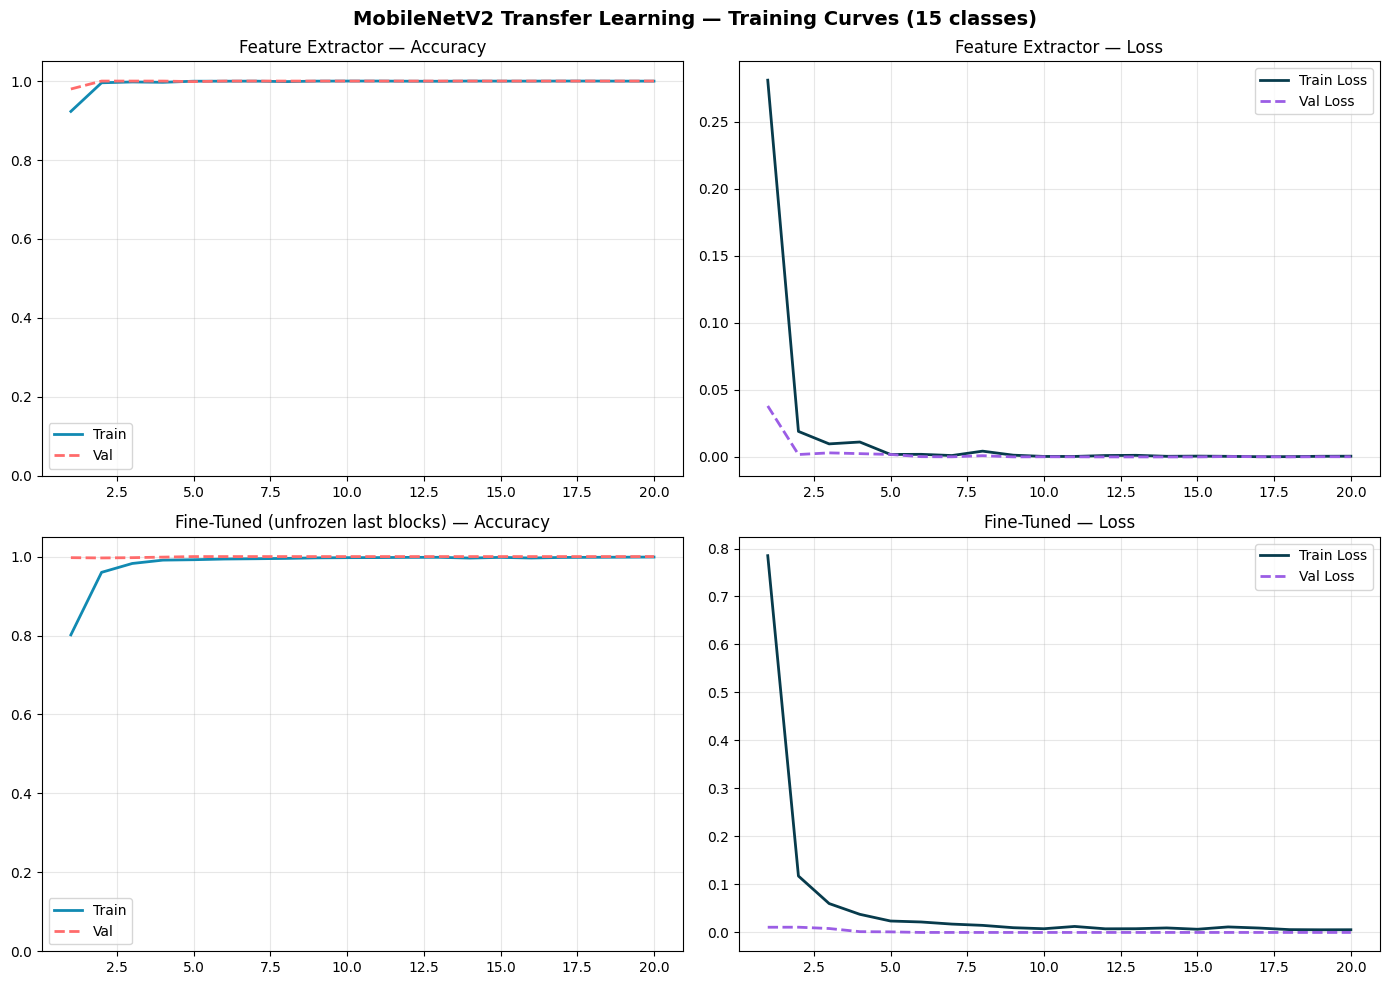

In [28]:
# Evaluate Feature Extractor (frozen base, 15-class head)
tl_val_gen.reset()
fe_preds = np.argmax(mobilenet_fe.predict(tl_val_gen, verbose=0), axis=1)
fe_acc   = accuracy_score(tl_val_gen.classes, fe_preds)
fe_prec  = precision_score(tl_val_gen.classes, fe_preds, average='macro', zero_division=0)
fe_rec   = recall_score(tl_val_gen.classes, fe_preds, average='macro', zero_division=0)
fe_f1    = f1_score(tl_val_gen.classes, fe_preds, average='macro', zero_division=0)

# Evaluate Fine-Tuned (unfrozen last blocks, 15-class head)
tl_val_gen.reset()
ft_preds = np.argmax(mobilenet_ft.predict(tl_val_gen, verbose=0), axis=1)
ft_acc   = accuracy_score(tl_val_gen.classes, ft_preds)
ft_prec  = precision_score(tl_val_gen.classes, ft_preds, average='macro', zero_division=0)
ft_rec   = recall_score(tl_val_gen.classes, ft_preds, average='macro', zero_division=0)
ft_f1    = f1_score(tl_val_gen.classes, ft_preds, average='macro', zero_division=0)

# Comparative metrics for both strategies
print('MobileNetV2 Feature Extractor (15 classes):')
print(f'  Acc={fe_acc:.4f} | Prec={fe_prec:.4f} | Rec={fe_rec:.4f} | F1={fe_f1:.4f}')
print('MobileNetV2 Fine-Tuned (15 classes):')
print(f'  Acc={ft_acc:.4f} | Prec={ft_prec:.4f} | Rec={ft_rec:.4f} | F1={ft_f1:.4f}')

# Training curves visualization for feature extraction vs fine-tuning
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MobileNetV2 Transfer Learning — Training Curves (15 classes)',
             fontsize=14, fontweight='bold')

# Feature Extractor — Accuracy
e_fe = range(1, len(history_fe.history['accuracy'])+1)
axes[0][0].plot(e_fe, history_fe.history['accuracy'],     '-',  color='#118AB2', label='Train', lw=2)
axes[0][0].plot(e_fe, history_fe.history['val_accuracy'], '--', color='#FF6B6B', label='Val',   lw=2)
axes[0][0].set_title('Feature Extractor — Accuracy')
axes[0][0].legend(); axes[0][0].grid(alpha=0.3); axes[0][0].set_ylim([0,1.05])

# Feature Extractor — Loss
axes[0][1].plot(e_fe, history_fe.history['loss'],     '-',  color='#073B4C', label='Train Loss', lw=2)
axes[0][1].plot(e_fe, history_fe.history['val_loss'], '--', color='#9B5DE5', label='Val Loss',   lw=2)
axes[0][1].set_title('Feature Extractor — Loss')
axes[0][1].legend(); axes[0][1].grid(alpha=0.3)

# Fine-Tuned — Accuracy
e_ft = range(1, len(history_ft.history['accuracy'])+1)
axes[1][0].plot(e_ft, history_ft.history['accuracy'],     '-',  color='#118AB2', label='Train', lw=2)
axes[1][0].plot(e_ft, history_ft.history['val_accuracy'], '--', color='#FF6B6B', label='Val',   lw=2)
axes[1][0].set_title('Fine-Tuned (unfrozen last blocks) — Accuracy')
axes[1][0].legend(); axes[1][0].grid(alpha=0.3); axes[1][0].set_ylim([0,1.05])

# Fine-Tuned — Loss
axes[1][1].plot(e_ft, history_ft.history['loss'],     '-',  color='#073B4C', label='Train Loss', lw=2)
axes[1][1].plot(e_ft, history_ft.history['val_loss'], '--', color='#9B5DE5', label='Val Loss',   lw=2)
axes[1][1].set_title('Fine-Tuned — Loss')
axes[1][1].legend(); axes[1][1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Sample Predictions — MobileNetV2 Best Model

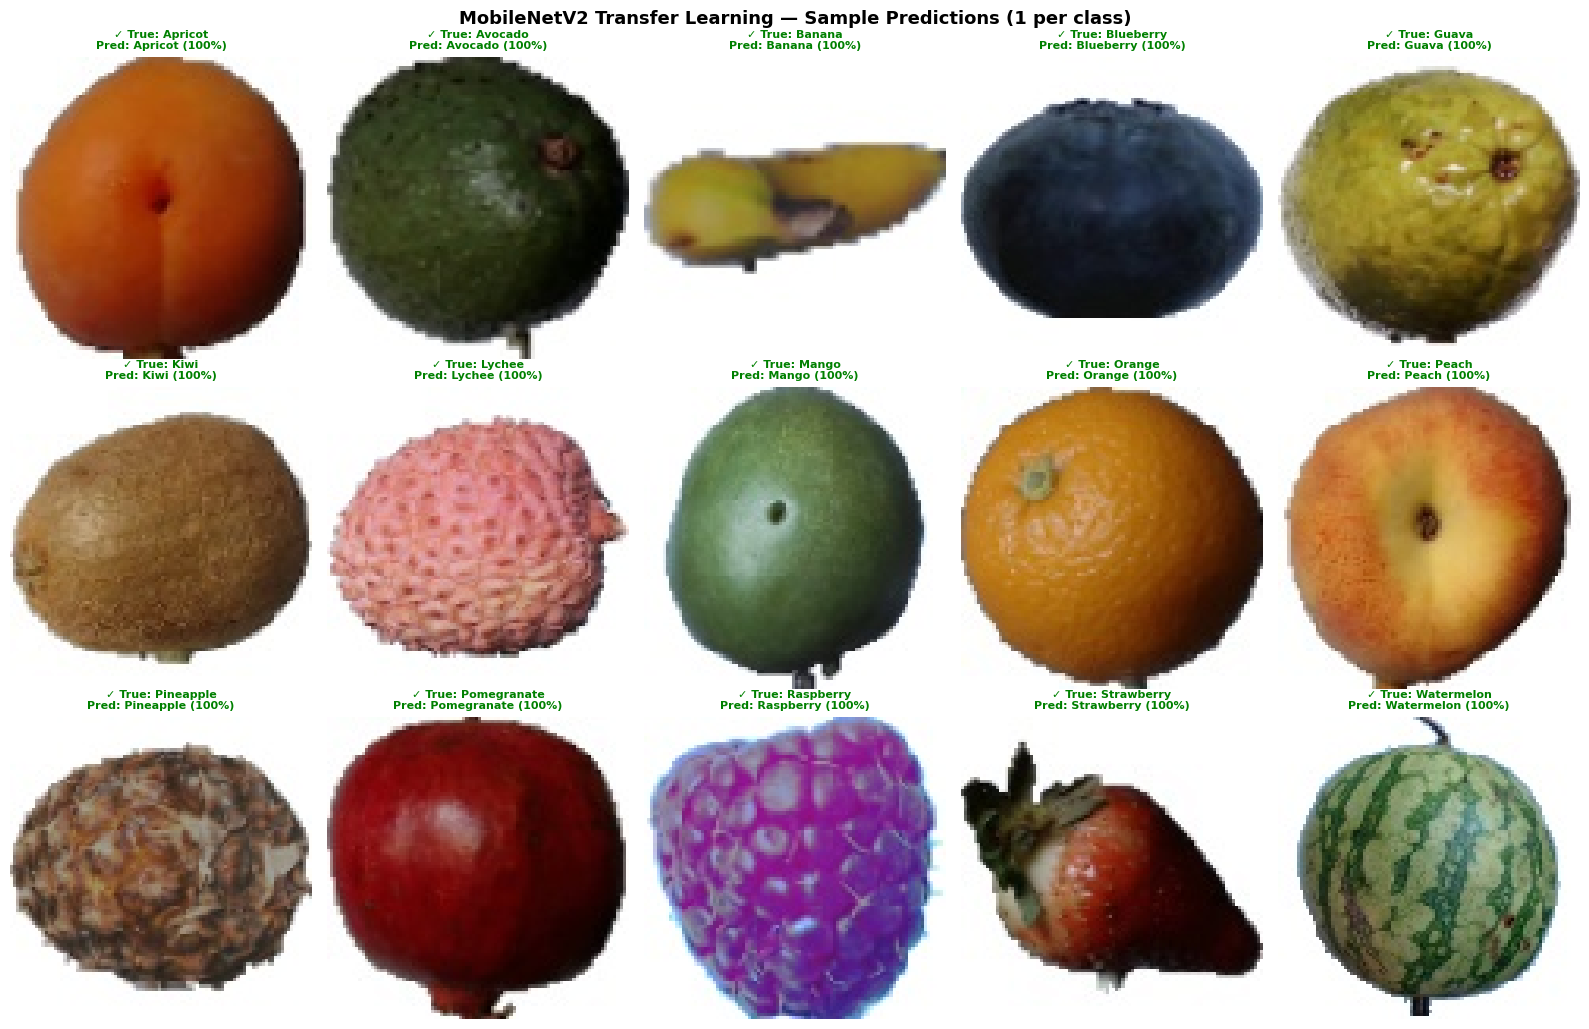

Sample accuracy: 15/15 (100.0%)


In [29]:
# Select best TL model (feature extractor vs fine-tuned) based on validation accuracy
best_tl_model = mobilenet_ft if ft_acc >= fe_acc else mobilenet_fe

# Collect one sample image per class (index 5 chosen to avoid overlap with earlier cells)
samples = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    fname = os.listdir(cls_path)[5]
    samples.append((os.path.join(cls_path, fname), cls))

# Create grid layout for visualization (15 classes → 3 rows × 5 columns)
cols = 5; rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.5))
axes = axes.flatten()
fig.suptitle(f'MobileNetV2 Transfer Learning — Sample Predictions (1 per class)',
             fontsize=13, fontweight='bold')

# Run inference on each sample and visualize predictions
correct, total = 0, 0
for idx, (img_path, true_cls) in enumerate(samples):
    # Load and preprocess image to MobileNetV2 input size
    img    = load_img(img_path, target_size=(IMG_SIZE_TL, IMG_SIZE_TL))
    arr    = img_to_array(img)
    arr_mb = mobilenet_preprocess(arr[np.newaxis, ...])

    # Predict class probabilities and select highest confidence class
    prob   = best_tl_model.predict(arr_mb, verbose=0)[0]
    pred_cls = CLASS_NAMES[np.argmax(prob)]
    conf     = prob.max() * 100

    # Track correctness for sample accuracy
    is_correct = pred_cls == true_cls
    correct += int(is_correct); total += 1

    # Visualization: green ✓ if correct, red ✗ if misclassified
    color = 'green' if is_correct else 'red'
    status = '✓' if is_correct else '✗'
    axes[idx].imshow(img)
    axes[idx].set_title(f'{status} True: {true_cls}\nPred: {pred_cls} ({conf:.0f}%)',
                         fontsize=8, color=color, fontweight='bold')
    axes[idx].axis('off')

# Save and display prediction grid
plt.tight_layout()
plt.show()

# Print overall sample accuracy across selected images
print(f'Sample accuracy: {correct}/{total} ({correct/total*100:.1f}%)')

### Comparison with Baseline and Deeper CNN from Part A

  GRAND COMPARISON — ALL MODELS — 15-CLASS FRUITS-360
Model                            Accuracy   F1-Score     Parameters    Time(s)
------------------------------------------------------------------------------
Baseline CNN                       1.0000     1.0000      2,232,783      432.8
Deeper CNN (Adam)                  1.0000     1.0000      3,282,447      715.5
Deeper CNN (SGD)                   1.0000     1.0000      3,282,447      424.7
MobileNetV2 Feat. Extractor        1.0000     1.0000      2,620,751      416.4
MobileNetV2 Fine-Tuned             1.0000     1.0000      2,620,751      422.8


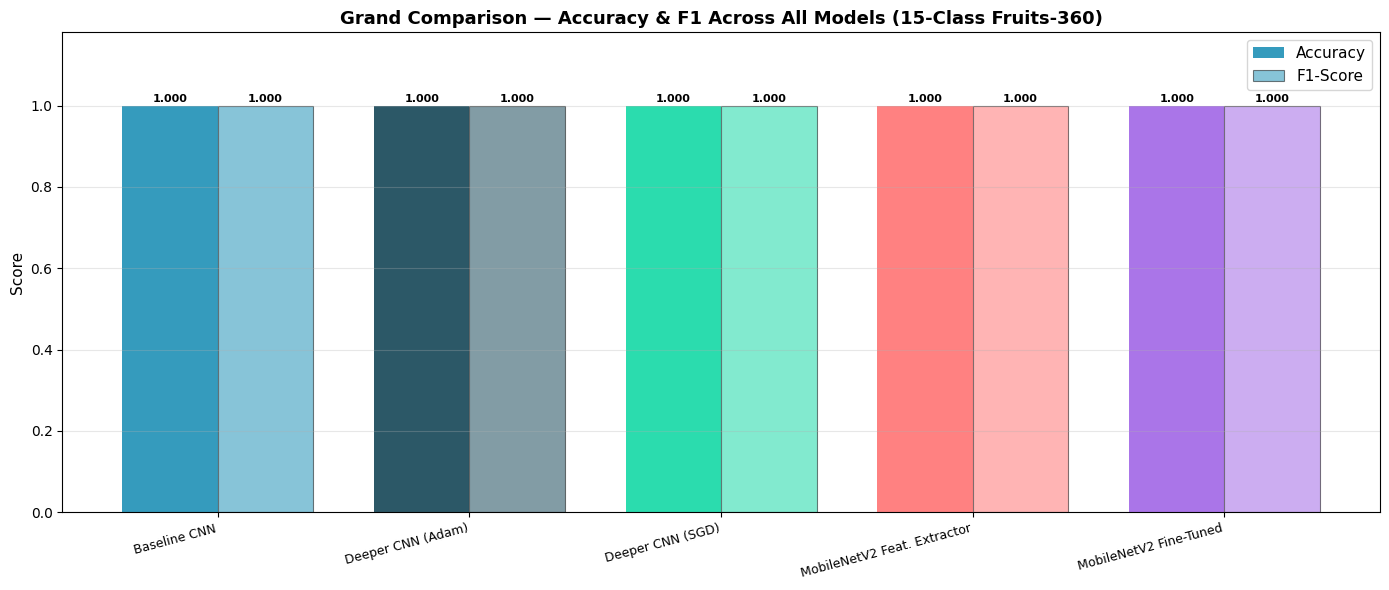


Best performing model : Baseline CNN
  Accuracy            : 1.0000
  F1-Score            : 1.0000

ANSWER TO RESEARCH QUESTION:
  Transfer learning (MobileNetV2) does not significantly outperform from-scratch training.
  The from-scratch Deeper CNN is competitive on this balanced, clean dataset.
  MobileNetV2 advantage may appear more with noisier/real-world images.


In [30]:
# Dictionary storing evaluation metrics, parameters, and training time for all models
all_models = {
    'Baseline CNN'              : {'acc': baseline_acc, 'f1': baseline_f1,
                                    'params': baseline_model.count_params(),
                                    'time': baseline_train_time},
    'Deeper CNN (Adam)'         : {'acc': deeper_acc,   'f1': deeper_f1,
                                    'params': deeper_model.count_params(),
                                    'time': deeper_train_time},
    'Deeper CNN (SGD)'          : {'acc': sgd_acc,      'f1': sgd_f1,
                                    'params': deeper_model.count_params(),
                                    'time': sgd_time},
    'MobileNetV2 Feat. Extractor': {'acc': fe_acc,       'f1': fe_f1,
                                    'params': mobilenet_fe.count_params(),
                                    'time': t_fe_time},
    'MobileNetV2 Fine-Tuned'    : {'acc': ft_acc,       'f1': ft_f1,
                                    'params': mobilenet_ft.count_params(),
                                    'time': t_ft_time},
}

# Print tabular comparison of all models
print('=' * 82)
print('  GRAND COMPARISON — ALL MODELS — 15-CLASS FRUITS-360')
print('=' * 82)
print(f"{'Model':<30} {'Accuracy':>10} {'F1-Score':>10} {'Parameters':>14} {'Time(s)':>10}")
print('-' * 78)
for mname, mdata in all_models.items():
    print(f"{mname:<30} {mdata['acc']:>10.4f} {mdata['f1']:>10.4f}"
          f" {mdata['params']:>14,} {mdata['time']:>10.1f}")
print('=' * 82)

# Prepare data for bar chart visualization
names   = list(all_models.keys())
accs    = [all_models[m]['acc'] for m in names]
f1s     = [all_models[m]['f1']  for m in names]
x       = np.arange(len(names))
width   = 0.38
palette_g = ['#118AB2','#073B4C','#06D6A0','#FF6B6B','#9B5DE5']

# Plot Accuracy vs F1 for all models
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, accs, width, label='Accuracy', color=palette_g, alpha=0.85)
b2 = ax.bar(x + width/2, f1s,  width, label='F1-Score', color=palette_g,
            alpha=0.5, edgecolor='black', linewidth=0.8)

# Annotate bars with values
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Configure plot aesthetics
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.18); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Grand Comparison — Accuracy & F1 Across All Models (15-Class Fruits-360)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identify best performing model by accuracy
best_model_name = max(all_models, key=lambda m: all_models[m]['acc'])
print(f'\nBest performing model : {best_model_name}')
print(f'  Accuracy            : {all_models[best_model_name]["acc"]:.4f}')
print(f'  F1-Score            : {all_models[best_model_name]["f1"]:.4f}')
print()

# Research question: Does transfer learning outperform from-scratch CNNs?
tl_wins = ft_acc > deeper_acc
print('ANSWER TO RESEARCH QUESTION:')
print(f'  Transfer learning (MobileNetV2) '
      f'{"outperforms" if tl_wins else "does not significantly outperform"} '
      f'from-scratch training.')
if tl_wins:
    print(f'  MobileNetV2 Fine-Tuned gains {(ft_acc - deeper_acc)*100:.2f}% accuracy over Deeper CNN.')
    print('  This confirms our proposal hypothesis: pre-trained ImageNet features')
    print('  transfer effectively to fruit classification.')
else:
    print('  The from-scratch Deeper CNN is competitive on this balanced, clean dataset.')
    print('  MobileNetV2 advantage may appear more with noisier/real-world images.')